In [16]:
COMPETITION_MODE = True
ROBOT_ID = 4
WORKER_ID=75
if COMPETITION_MODE:
    ROBOT_NAME = f"competition"
else:
    ROBOT_NAME = f"robot{ROBOT_ID}"

DEBUG_VIS = True
SAVE_LOGS = False
DATASET_LOGS = False
SAVE_DEBUG_PNGS = False

In [ ]:
# =========================
# Task1 debug helpers
# - image overlay
# - workspace plot (robot coordinate aligned)
# - eval endpoint fetch
# - step summary / history plot
# =========================
import os
import sys
import importlib
import importlib.util
import cv2
import math
import time
import json
import re
import types
import yaml
import csv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from pathlib import Path
from dotenv import load_dotenv

# =========================================================
# Map context globals
# =========================================================
workspace_cfg = None
mapper = None
X_MIN = X_MAX = Y_MIN = Y_MAX = None

ROBOT_MAP_DIR = None
LUT_PATH = None
CALIBRATION_YAML_PATH = None

SELECTED_CANDIDATE = None
best_lut = None
lut_ranking = None
probe_logs = None
ASSIGNED_ROBOT_NAME = None
state_hint = None
state_hint_ts = None
COMPETITION_RUN_STARTED = False

# =========================================================
# Bootstrap: RGMC project root
# =========================================================
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (
            (p / "src").exists()
            and (p / "configs").exists()
            and (p / "data").exists()
            and (p / "exec").exists()
        ):
            return p
    raise RuntimeError(
        f"Directory does not exists. start={start}, "
        "expected markers: src/, configs/, data/, exec/."
    )

CWD = Path.cwd().resolve()
PROJECT_ROOT = find_project_root(CWD)

SRC_ROOT = PROJECT_ROOT / "src"
CONFIG_ROOT = PROJECT_ROOT / "configs"
DATA_ROOT = PROJECT_ROOT / "data"
EXEC_ROOT = PROJECT_ROOT / "exec"

TASK1_DIR = SRC_ROOT / "task1"
CALIBRATION_DIR = SRC_ROOT / "calibration"
COMMON_CAMERA_DIR = SRC_ROOT / "common" / "camera"
CLOUDGRIPPER_CLIENT_DIR = SRC_ROOT / "cloudgripper-api" / "client"
DEBUG_DIR = CWD / "debug_task1_runtime"
EVALUATION_DIR = SRC_ROOT / "evaluation"
DATASET_DIR = CWD / "data"

LUT_CANDIDATE_DIR = DATA_ROOT / "lut_candidates"
HOMOGRAPHY_SIDECAR_DIR = DATA_ROOT / "lut_homography_sidecars"
LUT_GLOB = "lut_robot*.pkl"

MODEL_PATH = SRC_ROOT / "models" / "last.pt"


PROBE_SETTLE_SEC = 1.2
PROBE_CAPTURE_RETRIES = 3
PASSIVE_CAPTURE_FRAMES = 3
PASSIVE_CAPTURE_INTERVAL = 0.15
PASSIVE_LUT_WARN_ERR = 0.05

# Precomputed attach: Cell 1에서는 계산하지 않고, Cell 2에서 best LUT 선택 후 해당 .npz만 로드
ENABLE_HOMOGRAPHY_FALLBACK = True
HOMOGRAPHY_FALLBACK_CLAMP = False
HOMOGRAPHY_FALLBACK_VERBOSE = True
HOMOGRAPHY_FALLBACK_MAX_LOG = 10

print("CWD                :", CWD)
print("PROJECT_ROOT       :", PROJECT_ROOT)
print("SRC_ROOT           :", SRC_ROOT, SRC_ROOT.exists())
print("TASK1_DIR          :", TASK1_DIR, TASK1_DIR.exists())
print("CALIBRATION_DIR    :", CALIBRATION_DIR, CALIBRATION_DIR.exists())
print("COMMON_CAMERA_DIR  :", COMMON_CAMERA_DIR, COMMON_CAMERA_DIR.exists())
print("CLOUDGRIPPER_DIR   :", CLOUDGRIPPER_CLIENT_DIR, CLOUDGRIPPER_CLIENT_DIR.exists())
print("CONFIG_ROOT        :", CONFIG_ROOT)
print("DATA_ROOT          :", DATA_ROOT)
print("DEBUG_DIR          :", DEBUG_DIR)
print("LUT_CANDIDATE_DIR  :", LUT_CANDIDATE_DIR)
print("HOMOGRAPHY_SIDECAR_DIR:", HOMOGRAPHY_SIDECAR_DIR)
print("MODEL_PATH         :", MODEL_PATH)



# .env에서 CLOUDGRIPPER_TOKEN 로드
try:
    ENV_PATH = PROJECT_ROOT / ".env"
    load_dotenv(ENV_PATH)
    print("dotenv loaded from:", ENV_PATH)
except Exception as e:
    print("dotenv not used:", repr(e))

CLOUDGRIPPER_TOKEN = os.getenv("CLOUDGRIPPER_TOKEN")
if not CLOUDGRIPPER_TOKEN:
    raise RuntimeError("CLOUDGRIPPER_TOKEN not set.")
else:
    print("Token loaded")


# =========================================================
# Add project source directories to Python import path
# =========================================================
# PERCEPTION_DIR = TASK1_DIR / "perception"

# Fix this typo too: your current code has " evaluation" with a leading space
EVALUATION_DIR = SRC_ROOT / "evaluation"

IMPORT_DIRS = [
    SRC_ROOT,                  # allows: from task1.brain import ...
    TASK1_DIR,                 # allows task1-local imports if needed
    CALIBRATION_DIR,           # allows: from pixel_to_workspace import ...
    #COMMON_CAMERA_DIR,         # allows: import calib_fisheye_cam
    CLOUDGRIPPER_CLIENT_DIR,   # allows: from cloudgripper_client import ...
    #PERCEPTION_DIR,            # allows: import merged_T_det_refactored
    EVALUATION_DIR,            # allows: import shapes, evaluator files
]

for p in IMPORT_DIRS:
    if p.exists():
        p_str = str(p)
        if p_str not in sys.path:
            sys.path.insert(0, p_str)
            print("added to sys.path:", p)
    else:
        print("WARNING: path does not exist:", p)


# =========================================================
# config 충돌 방지
# =========================================================
for mod_name in [
    "config",
    "task1.config",
    "task1.brain",
    "task1.planner",
    "task1.robot_executor",
    "task1.motion_planner",
    "task1.total_",
    "task1.perf_utils",
]:
    if mod_name in sys.modules:
        del sys.modules[mod_name]

task1_config_path = TASK1_DIR / "config.py"
config_spec = importlib.util.spec_from_file_location("config", str(task1_config_path))
task1_config = importlib.util.module_from_spec(config_spec)
sys.modules["config"] = task1_config
assert config_spec.loader is not None
config_spec.loader.exec_module(task1_config)

print("config alias ->", task1_config.__file__)
print("config has PERF_LOG_SIM_EVERY:", hasattr(task1_config, "PERF_LOG_SIM_EVERY"))


# =========================================================
# Imports
# =========================================================
from cloudgripper_client import GripperRobot
from task1.brain import PushingBrain
from task1.planner import Planner
from task1.robot_executor import CloudGripperExecutor
from task1.push_geometry import get_global_corners, make_circle_polygon
from pixel_to_workspace import PixelToWorkspaceMapper
from shapes import SQUARE_CORNERS, CIRCLE_CORNERS, T_CORNERS

# -------------------------------------------------
# 0) robot coordinate -> plot coordinate
# -------------------------------------------------
# robot coord:
#   top-right  = (0, 0)
#   bottom-left= (1, 1)
#   horizontal axis = y
#   vertical axis   = x
#
# matplotlib plot coord:
#   bottom-left = (0, 0)
#   top-right   = (1, 1)
#   horizontal axis = x_plot
#   vertical axis   = y_plot
#
# therefore:
#   x_plot = y_robot
#   y_plot = 1 - x_robot
# -------------------------------------------------
def robot_to_plot(x_robot, y_robot):
    x_plot = 1.0 - float(y_robot)
    y_plot = 1.0 - float(x_robot)
    return x_plot, y_plot


def plot_to_robot(x_plot, y_plot):
    x_robot = 1.0 - float(y_plot)
    y_robot = float(x_plot)
    return x_robot, y_robot


def transform_polygon_robot_to_plot(poly_xy):
    if poly_xy is None:
        return None
    return [robot_to_plot(x, y) for (x, y) in poly_xy]


def close_poly(poly_xy):
    if poly_xy is None or len(poly_xy) == 0:
        return None
    pts = np.array(poly_xy, dtype=float)
    if not np.allclose(pts[0], pts[-1]):
        pts = np.vstack([pts, pts[0]])
    return pts


# -------------------------------------------------
# 1) generic polygon helpers
# -------------------------------------------------
def get_workspace_polygon_from_pose(shape_type, pose, task1_config):
    if pose is None:
        return None
    local_corners = task1_config.get_shape_corners(shape_type)
    radius = task1_config.get_shape_radius(shape_type)

    if shape_type == "circle":
        # circle 근사 polygon
        num_pts = 40
        cx, cy = pose[0], pose[1]
        r = radius
        th = np.linspace(0, 2 * np.pi, num_pts, endpoint=False)
        poly = [(cx + r * np.cos(t), cy + r * np.sin(t)) for t in th]
        return poly
    else:
        # get_global_corners 가 이미 노트북에 import 되어 있다고 가정
        return get_global_corners(pose, local_corners)


def workspace_polygon_to_pixel(poly_xy, mapper, clamp=False):
    if poly_xy is None:
        return None

    pixel_pts = []
    for x, y in poly_xy:
        try:
            uv = mapper.workspace_to_pixel(x, y)
        except Exception:
            try:
                uv = mapper.convert_xy_to_uv((x, y))
            except Exception:
                uv = None

        if uv is None:
            continue

        u, v = uv
        if np.isfinite(u) and np.isfinite(v):
            pixel_pts.append((int(round(u)), int(round(v))))
    return pixel_pts if len(pixel_pts) > 0 else None


def eval_geometry_points_to_cv(poly_dict):
    """
    eval_target / eval_object 형식:
      {'geometry': {'type': 'polygon', 'points': [{'x':..., 'y':...}, ...]}}
    """
    if poly_dict is None:
        return None
    try:
        pts = poly_dict["geometry"]["points"]
        return [(int(round(p["x"])), int(round(p["y"]))) for p in pts]
    except Exception:
        return None


def draw_cv_polygon(img, pts, color, thickness=2, closed=True):
    if pts is None or len(pts) < 2:
        return
    arr = np.array(pts, dtype=np.int32).reshape((-1, 1, 2))
    cv2.polylines(img, [arr], closed, color, thickness)


def draw_cv_point(img, pt, color, radius=5, text=None, text_offset=(6, -6)):
    if pt is None:
        return
    x, y = int(round(pt[0])), int(round(pt[1]))
    cv2.circle(img, (x, y), radius, color, -1)
    if text is not None:
        cv2.putText(
            img,
            str(text),
            (x + text_offset[0], y + text_offset[1]),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            1,
            cv2.LINE_AA,
        )


# -------------------------------------------------
# 2) eval endpoint fetch
# -------------------------------------------------
def fetch_eval_debug(robot):
    out = {
        "eval_target": None,
        "eval_object": None,
        "eval_status": None,
    }

    try:
        out["eval_target"] = robot.eval_target()
    except Exception as e:
        out["eval_target"] = {"error": repr(e)}

    try:
        out["eval_object"] = robot.eval_object()
    except Exception as e:
        out["eval_object"] = {"error": repr(e)}

    try:
        out["eval_status"] = robot.eval_status()
    except Exception as e:
        out["eval_status"] = {"error": repr(e)}

    return out


# -------------------------------------------------
# 4) workspace debug
# -------------------------------------------------

def draw_workspace_debug(
    step_idx,
    shape_type,
    current_pose,
    robot_xy,
    target_pose,
    plan=None,
    predicted_pose=None,
    observed_pose=None,
    title_suffix="",
    save_name=None,
    current_polygon_ws=None,
    target_polygon_ws=None,
    predicted_polygon_ws=None,
    observed_polygon_ws=None,
):
    """
    Workspace debug plot.

    Known shape:
        pose + template으로 polygon을 그림.


    """
    def _as_poly(poly):
        if poly is None:
            return None
        try:
            arr = np.asarray(poly, dtype=float)
            if arr.ndim != 2 or arr.shape[1] != 2 or len(arr) < 2:
                return None
            return [(float(x), float(y)) for x, y in arr]
        except Exception:
            return None

    def _pose_poly_safe(pose):
        if pose is None:
            return None
        try:
            return get_workspace_polygon_from_pose(shape_type, pose, task1_config)
        except Exception:
            # unknown/surprise shape에서는 pose/template이 없을 수 있다.
            # 이 경우 polygon_ws 인자를 직접 넣은 것만 그린다.
            return None

    # polygon이 직접 들어오면 그걸 우선 사용하고,
    # 없으면 기존 known shape pose/template 방식으로 그림.
    current_poly_ws = _as_poly(current_polygon_ws)
    if current_poly_ws is None:
        current_poly_ws = _pose_poly_safe(current_pose)

    target_poly_ws = _as_poly(target_polygon_ws)
    if target_poly_ws is None:
        target_poly_ws = _pose_poly_safe(target_pose)

    pred_poly_ws = _as_poly(predicted_polygon_ws)
    if pred_poly_ws is None:
        pred_poly_ws = _pose_poly_safe(predicted_pose)

    obs_poly_ws = _as_poly(observed_polygon_ws)
    if obs_poly_ws is None:
        obs_poly_ws = _pose_poly_safe(observed_pose)

    # robot-coordinate -> plot-coordinate 변환
    current_poly_plot = transform_polygon_robot_to_plot(current_poly_ws)
    target_poly_plot = transform_polygon_robot_to_plot(target_poly_ws)
    pred_poly_plot = transform_polygon_robot_to_plot(pred_poly_ws)
    obs_poly_plot = transform_polygon_robot_to_plot(obs_poly_ws)

    plt.figure(figsize=(7, 7))
    ax = plt.gca()

    # workspace boundary
    boundary_robot = [(0, 0), (0, 1), (1, 1), (1, 0)]
    boundary_plot = transform_polygon_robot_to_plot(boundary_robot)
    boundary_plot = close_poly(boundary_plot)
    ax.plot(boundary_plot[:, 0], boundary_plot[:, 1], 'k--', alpha=0.5, label='workspace_0_1')

    # planner workspace boundary (config 기준)
    planner_ws_robot = [
        (task1_config.WORKSPACE_MIN[0], task1_config.WORKSPACE_MIN[1]),
        (task1_config.WORKSPACE_MAX[0], task1_config.WORKSPACE_MIN[1]),
        (task1_config.WORKSPACE_MAX[0], task1_config.WORKSPACE_MAX[1]),
        (task1_config.WORKSPACE_MIN[0], task1_config.WORKSPACE_MAX[1]),
    ]
    planner_ws_plot = transform_polygon_robot_to_plot(planner_ws_robot)
    planner_ws_plot = close_poly(planner_ws_plot)
    ax.plot(
        planner_ws_plot[:, 0],
        planner_ws_plot[:, 1],
        color='purple',
        linestyle=':',
        linewidth=2,
        label='planner_ws'
    )

    # target
    if target_poly_plot is not None:
        pts = close_poly(target_poly_plot)
        ax.plot(pts[:, 0], pts[:, 1], color='green', linewidth=2, label='target')

    # current
    if current_poly_plot is not None:
        pts = close_poly(current_poly_plot)
        ax.plot(pts[:, 0], pts[:, 1], color='red', linewidth=2, label='current')

    # robot
    if robot_xy is not None:
        rx, ry = robot_to_plot(robot_xy[0], robot_xy[1])
        ax.scatter([rx], [ry], color='tab:blue', s=40, label='robot', zorder=5)

    # predicted
    if pred_poly_plot is not None:
        pts = close_poly(pred_poly_plot)
        ax.plot(pts[:, 0], pts[:, 1], color='magenta', linewidth=2, label='predicted')

    # observed
    if obs_poly_plot is not None:
        pts = close_poly(obs_poly_plot)
        ax.plot(pts[:, 0], pts[:, 1], color='black', linewidth=2, label='observed')

    # plan: push line / approach path / retreat
    start_xy = end_xy = approach_path = retreat_xy = None
    sx = sy = ex = ey = None
    tx = ty = None
    ap_plot = None

    if plan is not None:
        cand = plan.get("candidate", {})
        motion = plan.get("motion", {})

        # push line
        start_xy = cand.get("start", None)
        end_xy = cand.get("end", None)
        if start_xy is not None and end_xy is not None:
            sx, sy = robot_to_plot(start_xy[0], start_xy[1])
            ex, ey = robot_to_plot(end_xy[0], end_xy[1])
            ax.plot([sx, ex], [sy, ey], color='orange', linewidth=3, label='push_line')

        # approach path
        approach_path = motion.get("approach_path", None)
        if approach_path is not None and len(approach_path) > 0:
            ap_plot = [robot_to_plot(p[0], p[1]) for p in approach_path]
            ap_plot = np.array(ap_plot, dtype=float)
            ax.plot(
                ap_plot[:, 0], ap_plot[:, 1],
                linestyle='--', color='tab:green', linewidth=2, label='approach_path'
            )

        # retreat
        retreat_xy = motion.get("retreat_xy", None)
        if retreat_xy is not None:
            tx, ty = robot_to_plot(retreat_xy[0], retreat_xy[1])
            ax.scatter([tx], [ty], marker='x', s=100, color='tab:red', label='retreat', zorder=6)

    # axis style
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')

    # 눈금 라벨을 로봇 좌표 느낌으로 보조 표시
    ax.set_xlabel("plot x  (robot y)")
    ax.set_ylabel("plot y  (1 - robot x)")
    ax.set_title(f"Step {step_idx} workspace debug {title_suffix}")

    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    plt.show()

    if SAVE_DEBUG_PNGS and save_name is not None:
        save_path = DEBUG_DIR / save_name
        plt.figure(figsize=(7, 7))
        ax = plt.gca()

        # redraw for save
        ax.plot(boundary_plot[:, 0], boundary_plot[:, 1], 'k--', alpha=0.5, label='workspace_0_1')
        ax.plot(
            planner_ws_plot[:, 0],
            planner_ws_plot[:, 1],
            color='purple',
            linestyle=':',
            linewidth=2,
            label='planner_ws'
        )

        if target_poly_plot is not None:
            pts = close_poly(target_poly_plot)
            ax.plot(pts[:, 0], pts[:, 1], color='green', linewidth=2, label='target')
        if current_poly_plot is not None:
            pts = close_poly(current_poly_plot)
            ax.plot(pts[:, 0], pts[:, 1], color='red', linewidth=2, label='current')
        if robot_xy is not None:
            ax.scatter([rx], [ry], color='tab:blue', s=40, label='robot', zorder=5)
        if pred_poly_plot is not None:
            pts = close_poly(pred_poly_plot)
            ax.plot(pts[:, 0], pts[:, 1], color='magenta', linewidth=2, label='predicted')
        if obs_poly_plot is not None:
            pts = close_poly(obs_poly_plot)
            ax.plot(pts[:, 0], pts[:, 1], color='black', linewidth=2, label='observed')

        if plan is not None:
            if start_xy is not None and end_xy is not None:
                ax.plot([sx, ex], [sy, ey], color='orange', linewidth=3, label='push_line')
            if approach_path is not None and len(approach_path) > 0 and ap_plot is not None:
                ax.plot(
                    ap_plot[:, 0], ap_plot[:, 1],
                    linestyle='--', color='tab:green', linewidth=2, label='approach_path'
                )
            if retreat_xy is not None:
                ax.scatter([tx], [ty], marker='x', s=100, color='tab:red', label='retreat', zorder=6)

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect('equal')
        ax.set_xlabel("plot x  (robot y)")
        ax.set_ylabel("plot y  (1 - robot x)")
        ax.set_title(f"Step {step_idx} workspace debug {title_suffix}")
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()

def print_step_summary(h):
    print("\n" + "-" * 80)
    print(f"[STEP SUMMARY] step={h.get('step')}")
    print("-" * 80)
    print("shape_type           :", h.get("shape_type"))
    print("current_pose         :", h.get("current_pose"))
    print("target_pose          :", h.get("target_pose"))
    print("robot_xy             :", h.get("robot_xy"))
    print("num_feasible         :", h.get("num_feasible"))
    print("attach_fail_count    :", h.get("attach_fail_count"))
    print("execute_ok           :", h.get("execute_ok"))
    print("official_iou_before  :", h.get("official_iou_before"))
    print("official_iou_after   :", h.get("official_iou_after"))
    print("rgmc_iou             :", h.get("rgmc_iou"))
    print("predicted_next_pose  :", h.get("predicted_next_pose"))
    print("observed_pose_after  :", h.get("observed_pose_after"))
    print("dx_err               :", h.get("dx_err"))
    print("dy_err               :", h.get("dy_err"))
    print("dtheta_err           :", h.get("dtheta_err"))
    print("pos_err_norm         :", h.get("pos_err_norm"))
    print("stop_reason          :", h.get("stop_reason"))

    esb = h.get("eval_status_before")
    esa = h.get("eval_status_after")
    if esb is not None:
        print("eval_status_before   :", esb)
    if esa is not None:
        print("eval_status_after    :", esa)


# -------------------------------------------------
# 6) history plot
# -------------------------------------------------
def plot_history(history):
    if history is None or len(history) == 0:
        print("history is empty")
        return

    steps = [h["step"] for h in history]

    def _vals(key):
        out = []
        for h in history:
            v = h.get(key, None)
            out.append(np.nan if v is None else v)
        return out

    plt.figure(figsize=(10, 5))
    plt.plot(steps, _vals("official_iou_before"), marker='o', label='official_iou_before')
    plt.plot(steps, _vals("official_iou_after"), marker='o', label='official_iou_after')
    plt.plot(steps, _vals("rgmc_iou"), marker='o', label='rgmc_iou_debug')
    plt.xlabel("step")
    plt.ylabel("IoU")
    plt.title("Task1 runtime history - official IoU")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(steps, _vals("num_feasible"), marker='o', label='num_feasible')
    plt.plot(steps, _vals("attach_fail_count"), marker='o', label='attach_fail_count')
    plt.xlabel("step")
    plt.ylabel("count")
    plt.title("Task1 runtime history - planner feasibility")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # =========================================================
# User settings
# =========================================================
# False: use your current fixed ROBOT_ID / data/map/robotXX/lut.pkl method.
# True : connect through "competition" and select the correct LUT from data/lut_candidates/.



EXECUTE_PUSH = True

USABLE_WORKSPACE_X_MM = 150.0
USABLE_WORKSPACE_Y_MM = 150.0

# Stable state read parameters.
# These are used by both the main loop and passive LUT selection.
STATE_STABLE_MAX_TRIES = 8
STATE_STABLE_INTERVAL = 0.20
STATE_STABLE_TOL = 0.01
STATE_STABLE_REQUIRED_CONSECUTIVE = 2

'''
ROBOT_MAP_DIR = DATA_ROOT / "map" / ROBOT_NAME
LUT_PATH = ROBOT_MAP_DIR / "lut.pkl"

CALIBRATION_YAML_PATH = CONFIG_ROOT / "calibration" / f"calibration_{ROBOT_NAME}.yaml"
'''
def load_workspace_bounds_from_calibration_yaml(yaml_path):
    yaml_path = Path(yaml_path)
    if not yaml_path.exists():
        raise FileNotFoundError(f"Calibration yaml not found: {yaml_path}")

    with open(yaml_path, "r", encoding="utf-8") as f:
        data = yaml.safe_load(f)

    if not isinstance(data, dict):
        raise RuntimeError(f"Calibration yaml must load to dict: {yaml_path}")

    section_candidates = [
        "rope_calibration",
        "calibration",
        "task1_calibration",
        "planar_push_calibration",
    ]

    section_name = None
    section = None
    for name in section_candidates:
        cand = data.get(name, None)
        if isinstance(cand, dict) and all(k in cand for k in ["x_min", "x_max", "y_min", "y_max"]):
            section_name = name
            section = cand
            break

    if section is None:
        raise RuntimeError(
            f"x_min/x_max/y_min/y_max not found in calibration yaml: {yaml_path}"
        )

    x_min = float(section["x_min"])
    x_max = float(section["x_max"])
    y_min = float(section["y_min"])
    y_max = float(section["y_max"])

    if not (x_min < x_max and y_min < y_max):
        raise ValueError(
            f"Invalid workspace bounds in {yaml_path}: "
            f"x=({x_min}, {x_max}), y=({y_min}, {y_max})"
        )

    return {
        "section_name": section_name,
        "x_min": x_min,
        "x_max": x_max,
        "y_min": y_min,
        "y_max": y_max,
    }

# =========================================================
# Helper functions
# =========================================================
def get_undistorted_image(robot):
    out = robot.getImageBaseUndistorted()
    if isinstance(out, tuple):
        img_proc, ts_img = out
    else:
        img_proc, ts_img = out, None

    if not isinstance(img_proc, np.ndarray):
        raise TypeError(
            f"Expected np.ndarray from robot.getImageBaseUndistorted(), got {type(img_proc)}"
        )
    return img_proc, ts_img


def unpack_robot_state_out(state_out):
    """
    robot.get_state() output defensive unpacker.

    Supported forms:
      1) (state_dict, timestamp)
      2) state_dict
      3) {"state": state_dict, "timestamp": ...}
      4) None / unexpected response -> (None, None)
    """
    if state_out is None:
        return None, None

    if isinstance(state_out, tuple):
        if len(state_out) >= 2:
            return state_out[0], state_out[1]
        if len(state_out) == 1:
            return state_out[0], None
        return None, None

    if isinstance(state_out, dict):
        if "state" in state_out:
            return state_out.get("state"), state_out.get("timestamp", None)

        if "x_norm" in state_out and "y_norm" in state_out:
            return state_out, state_out.get("timestamp", None)

    return None, None


def get_robot_xy_from_state(state):
    """
    Safely extract robot xy from a CloudGripper state dict.
    Returns None instead of raising if the state is temporarily unavailable.
    """
    if state is None:
        return None

    if not isinstance(state, dict):
        return None

    try:
        if "x_norm" in state and "y_norm" in state:
            x = float(state["x_norm"])
            y = float(state["y_norm"])
        elif "x" in state and "y" in state:
            x = float(state["x"])
            y = float(state["y"])
        else:
            return None

        if not np.isfinite(x) or not np.isfinite(y):
            return None

        return [x, y]

    except Exception:
        return None


def get_stable_robot_state(
    robot,
    max_tries=None,
    interval=None,
    tol=None,
    required_consecutive=None,
):
    if max_tries is None:
        max_tries = STATE_STABLE_MAX_TRIES
    if interval is None:
        interval = STATE_STABLE_INTERVAL
    if tol is None:
        tol = STATE_STABLE_TOL
    if required_consecutive is None:
        required_consecutive = STATE_STABLE_REQUIRED_CONSECUTIVE

    samples = []
    prev_xy = None
    stable_count = 0
    last_state = None
    last_ts = None

    for k in range(int(max_tries)):
        try:
            state_out = robot.get_state()   
        except Exception as e:
            samples.append({
                "try": int(k + 1),
                "xy": None,
                "ts": None,
                "ok": False,
                "error": repr(e),
            })
            if k < int(max_tries) - 1:
                time.sleep(float(interval))
            continue

        state, ts = unpack_robot_state_out(state_out)
        xy = get_robot_xy_from_state(state)

        if xy is None:
            samples.append({
                "try": int(k + 1),
                "xy": None,
                "ts": ts,
                "ok": False,
                "raw_type": type(state_out).__name__,
            })
            if k < int(max_tries) - 1:
                time.sleep(float(interval))
            continue

        samples.append({
            "try": int(k + 1),
            "xy": [float(xy[0]), float(xy[1])],
            "ts": ts,
            "ok": True,
        })

        if prev_xy is not None:
            dist = float(np.hypot(xy[0] - prev_xy[0], xy[1] - prev_xy[1]))
            if dist <= float(tol):
                stable_count += 1
            else:
                stable_count = 0

            if stable_count >= int(required_consecutive):
                return state, ts, True, samples

        prev_xy = xy
        last_state = state
        last_ts = ts

        if k < int(max_tries) - 1:
            time.sleep(float(interval))

    if last_state is not None:
        print("[WARN] robot state was not confirmed stable; using last valid state")
        return last_state, last_ts, False, samples

    raise RuntimeError(
        "[ERROR] robot.get_state() returned no valid state. "
        f"samples={samples}"
    )


def show_bgr(img, title="image", figsize=(6, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


def pretty_print(obj, title=None):
    if title:
        print(f"\n[{title}]")
    import pprint
    pprint.pprint(obj)


def select_task_object(task_inputs):
    if not task_inputs:
        return None
    return task_inputs[0]


def get_local_corners_and_radius(shape_type):
    local_corners = task1_config.get_shape_corners(shape_type)
    radius = task1_config.get_shape_radius(shape_type)
    return local_corners, radius


def build_world_polygon(shape_type, pose, local_corners, radius):
    if shape_type == "circle":
        return make_circle_polygon(pose[:2], radius, task1_config.CIRCLE_POLY_POINTS)
    return get_global_corners(pose, local_corners)


def compute_internal_iou(current_pose, shape_type, target_pose):
    planner = Planner(task1_config)
    
    local_corners, radius = get_local_corners_and_radius(shape_type)

    cur_poly = build_world_polygon(shape_type, current_pose, local_corners, radius)
    tgt_poly = build_world_polygon(shape_type, target_pose, local_corners, radius)

    iou = planner.calculate_iou(
        planner.world_to_mask(cur_poly),
        planner.world_to_mask(tgt_poly),
        planner.mask_shape,
    )
    return float(iou), cur_poly, tgt_poly


def workspace_pose_to_rgmc_mm(target_pose, usable_x_mm=150.0, usable_y_mm=150.0):
    x_norm, y_norm, theta = target_pose
    offset_x_mm = (float(x_norm) - 0.5) * float(usable_x_mm)
    offset_y_mm = (0.5 - float(y_norm)) * float(usable_y_mm)
    return [offset_x_mm, offset_y_mm], float(theta)


def get_eval_shape_corners_mm(shape_type):
    if shape_type == "square":
        return SQUARE_CORNERS
    if shape_type == "circle":
        return CIRCLE_CORNERS
    if shape_type == "t":
        return T_CORNERS
    raise ValueError(f"Unsupported shape_type: {shape_type}")


def summarize_plan(plan):
    if plan is None:
        print("plan: None")
        return
    cand = plan["candidate"]
    motion = plan["motion"]
    print("score:", plan["score"])
    print("progress:", plan["progress"])
    print("align:", plan["align"])
    print("current_shape_err:", plan["current_shape_err"])
    print("next_shape_err:", plan["next_shape_err"])
    print("start:", cand["start"])
    print("end:", cand["end"])
    print("n_hat:", cand["n_hat"])
    print("t_hat:", cand["t_hat"])
    print("approach_path_len:", len(motion["approach_path"]))
    print("approach_xy:", motion["approach_xy"])
    print("retreat_xy:", motion["retreat_xy"])


def extract_coords_2d(result):
    if result is None:
        return None
    try:
        return [[p["x"], p["y"]] for p in result["geometry"]["points"]]
    except (KeyError, TypeError):
        return None

def wrap_angle_rad(a):
    return (a + math.pi) % (2.0 * math.pi) - math.pi

def _as_uv_array(points_uv):
    """eval_target geometry points를 (N, 2) float64 UV 배열로 변환."""
    out = []
    for p in points_uv:
        if isinstance(p, dict):
            out.append([float(p["x"]), float(p["y"])])
        else:
            out.append([float(p[0]), float(p[1])])
    return np.asarray(out, dtype=np.float64)

def square_target_pose_from_eval(points_uv, mapper):
    pts = np.array(points_uv, dtype=np.float32)
    if pts.shape != (4, 2):
        raise ValueError("square target points must have shape (4, 2)")

    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1).reshape(-1)

    top_left = pts[np.argmin(s)]
    bottom_right = pts[np.argmax(s)]
    top_right = pts[np.argmin(diff)]
    bottom_left = pts[np.argmax(diff)]

    ordered = np.array([top_left, top_right, bottom_right, bottom_left], dtype=np.float32)

    center_uv = ordered.mean(axis=0)
    edge = ordered[1] - ordered[0]
    theta_rad = float(np.arctan2(edge[1], edge[0]))

    x_norm, y_norm = mapper.convert_one(float(center_uv[0]), float(center_uv[1]))
    return [float(x_norm), float(y_norm), float(theta_rad)]


def circle_target_pose_from_eval(points_uv, mapper):
    pts = np.array(points_uv, dtype=np.float32)
    if pts.ndim != 2 or pts.shape[1] != 2 or len(pts) < 3:
        raise ValueError("circle target points must have shape (N, 2), N >= 3")

    # polygon으로 들어온 원 target의 중심 추정
    cnt = pts.reshape(-1, 1, 2)
    M = cv2.moments(cnt)

    if abs(M["m00"]) < 1e-8:
        # 예외적으로 면적 계산이 불안정하면 평균점으로 fallback
        center_uv = pts.mean(axis=0)
    else:
        cx = float(M["m10"] / M["m00"])
        cy = float(M["m01"] / M["m00"])
        center_uv = np.array([cx, cy], dtype=np.float32)

    x_norm, y_norm = mapper.convert_one(float(center_uv[0]), float(center_uv[1]))

    # circle은 orientation 의미가 없으므로 0으로 둠
    theta_rad = 0.0
    return [float(x_norm), float(y_norm), float(theta_rad)]




def _rigid_fit_2d(local_pts, world_pts):
    """
    local_pts -> world_pts 를 가장 잘 맞추는 2D rigid transform 계산.
    world ≈ R @ local + t
    """
    local_pts = np.asarray(local_pts, dtype=np.float64)
    world_pts = np.asarray(world_pts, dtype=np.float64)

    if local_pts.shape != world_pts.shape:
        raise ValueError(f"local/world shape mismatch: {local_pts.shape} vs {world_pts.shape}")

    local_mean = local_pts.mean(axis=0)
    world_mean = world_pts.mean(axis=0)

    A = local_pts - local_mean
    B = world_pts - world_mean

    H = A.T @ B
    U, S, Vt = np.linalg.svd(H)

    R = Vt.T @ U.T

    # reflection 방지: 실제 T template을 뒤집는 해는 brain 기준 pose로 쓸 수 없음
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1.0
        R = Vt.T @ U.T

    t = world_mean - R @ local_mean

    pred = (R @ local_pts.T).T + t
    rmse = float(np.sqrt(np.mean(np.sum((pred - world_pts) ** 2, axis=1))))
    theta = math.atan2(R[1, 0], R[0, 0])

    return R, t, theta, rmse, pred


def _iter_template_orders(template_pts):
    """
    eval_target T polygon의 시작 꼭짓점/방향이 달라질 수 있으므로
    cyclic shift + reverse를 전부 검사한다.
    """
    template_pts = np.asarray(template_pts, dtype=np.float64)
    n = len(template_pts)

    for reverse in [False, True]:
        base = template_pts[::-1].copy() if reverse else template_pts.copy()
        for shift in range(n):
            yield np.roll(base, shift, axis=0), reverse, shift


def t_target_pose_from_eval(points_uv, mapper):
    """
    eval_target에서 받은 T polygon 8점을
    task1_config.get_shape_corners("T_BASE") 기준 pose [x, y, theta]로 변환.

    기존 moment/PCA 방식은 T자에서 90도 convention 문제가 생길 수 있어서 사용하지 않는다.
    대신 eval_target 8점을 workspace XY로 변환한 뒤, brain이 실제로 쓰는 T template과
    Kabsch rigid fitting을 수행한다.
    """
    uv = _as_uv_array(points_uv)

    if uv.ndim != 2 or uv.shape[1] != 2:
        raise ValueError("points must have shape (N, 2)")
    if len(uv) != 8:
        raise ValueError(f"T target expects 8 points, got {len(uv)}")

    # 1) eval_target pixel UV -> workspace XY
    world_pts = []
    for u, v in uv:
        x_norm, y_norm = mapper.convert_one(float(u), float(v))
        world_pts.append([float(x_norm), float(y_norm)])
    world_pts = np.asarray(world_pts, dtype=np.float64)

    # 2) brain/planner가 실제로 쓰는 T template
    template = np.asarray(task1_config.get_shape_corners("t"), dtype=np.float64)

    if template.shape != world_pts.shape:
        raise ValueError(f"T template shape mismatch: template={template.shape}, target={world_pts.shape}")

    # 3) 꼭짓점 순서/역순을 모두 검사해서 RMSE가 가장 작은 pose 선택
    best = None
    for cand_template, reverse, shift in _iter_template_orders(template):
        R, t, theta, rmse, pred = _rigid_fit_2d(cand_template, world_pts)

        if best is None or rmse < best["rmse"]:
            best = {
                "R": R,
                "t": t,
                "theta": theta,
                "rmse": rmse,
                "pred": pred,
                "reverse": reverse,
                "shift": shift,
            }

    x_norm, y_norm = best["t"]
    theta_rad = wrap_angle_rad(best["theta"])

    print(
        "[T target Kabsch] "
        f"x={x_norm:.5f}, y={y_norm:.5f}, "
        f"theta_deg={math.degrees(theta_rad):.2f}, "
        f"rmse={best['rmse']:.5f}, "
        f"reverse={best['reverse']}, shift={best['shift']}"
    )

    # 15cm workspace 기준 0.025는 약 3.75mm. 이보다 크면 mapper/template mismatch 가능성이 큼.
    if best["rmse"] > 0.025:
        print("[WARN] T target Kabsch RMSE is large. Check mapper, T_BASE_SCALE, or vertex order.")

    return [float(x_norm), float(y_norm), float(theta_rad)]
    
def calculate_pose(target_data, target_object, mapper):
    if target_data is None:
        raise RuntimeError("No target data received from robot.eval_target()")

    target_points = extract_coords_2d(target_data)

    if target_points is None or len(target_points) == 0:
        raise RuntimeError(f"Invalid target geometry received: {target_data}")

    if target_object == "square":
        return square_target_pose_from_eval(target_points, mapper)

    if target_object == "circle":
        return circle_target_pose_from_eval(target_points, mapper)
    
    if target_object == "t":
        return t_target_pose_from_eval(target_points, mapper)

    raise NotImplementedError(
        f"Target conversion for '{target_object}' is not implemented yet. "
        "Currently supported: 'square', 'circle', 't'"
    )


def eval_polygon_to_workspace_payload(eval_data, mapper):
    """
    robot.eval_target() / robot.eval_object() polygon payload을
    brain.get_best_plan_polygon()에서 쓰는 normalized workspace polygon으로 변환한다.

    - coordinate_space가 undistorted_pixel_2d/pixel이면 mapper.convert_one(u, v) 사용
    - 이미 workspace 좌표처럼 보이면 그대로 사용
    """
    if eval_data is None:
        return None

    try:
        points = eval_data["geometry"]["points"]
    except Exception:
        print("[POLYGON CONVERT] invalid eval_data:", eval_data)
        return None

    coord_space = str(eval_data.get("coordinate_space", "")).lower()
    use_mapper = ("pixel" in coord_space) or ("undistorted" in coord_space)

    out = []
    for p in points:
        try:
            u = float(p["x"])
            v = float(p["y"])

            # payload이 pixel 좌표이거나 값이 1보다 훨씬 크면 mapper로 변환
            if use_mapper or max(abs(u), abs(v)) > 2.0:
                if not hasattr(mapper, "convert_one"):
                    raise TypeError("mapper.convert_one(u, v) is required for pixel polygon")
                x_norm, y_norm = mapper.convert_one(u, v)
            else:
                x_norm, y_norm = u, v

            out.append([float(x_norm), float(y_norm)])
        except Exception as e:
            print("[POLYGON CONVERT] point convert failed:", p, repr(e))

    if len(out) < 3:
        print("[POLYGON CONVERT] too few converted points:", out)
        return None

    poly = np.asarray(out, dtype=float)
    print(
        "[POLYGON CONVERT]",
        "coord_space=", eval_data.get("coordinate_space"),
        "n=", len(poly),
        "x_range=", (float(poly[:, 0].min()), float(poly[:, 0].max())),
        "y_range=", (float(poly[:, 1].min()), float(poly[:, 1].max())),
    )
    return poly


# =========================================================
# Competition-mode LUT candidate selection helpers
# =========================================================
# These helpers are lazy:
# - In fixed mode, they are defined but do not preload LUTs or load YOLO.
# - In competition mode, choose_lut_context() loads candidates and only loads YOLO if passive selection is needed.

LUT_CANDIDATES = None
gripper_detector = None


def _robot_digits_from_name(robot_name):
    digits = "".join(ch for ch in str(robot_name) if ch.isdigit())
    if not digits:
        return None
    return digits


def normalize_robot_name(value):
    if value is None:
        return None

    s = str(value).strip()
    if not s:
        return None

    digits = "".join(ch for ch in s if ch.isdigit())
    if digits:
        return f"robot{int(digits)}"

    return s.lower()


def parse_robot_name_from_lut_filename(path):
    path = Path(path)
    stem = path.stem

    m = re.search(r"robot[_\-]?(\d+)", stem, flags=re.IGNORECASE)
    if m is None:
        raise ValueError(f"robot id parse failed from LUT filename: {path.name}")

    # Normalize robot06 -> robot6 for downstream names.
    return f"robot{int(m.group(1))}"


def _first_existing_path(paths, default=None):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return default if default is not None else Path(paths[0])


def _candidate_calibration_yaml_path(robot_digits, robot_name):
    nozero_name = f"robot{int(robot_digits)}"
    padded_name = f"robot{int(robot_digits):02d}"

    candidates = [
        CONFIG_ROOT / "calibration" / f"calibration_{nozero_name}.yaml",
        CONFIG_ROOT / "calibration" / f"calibration_{padded_name}.yaml",
        CONFIG_ROOT / "calibration" / f"calibration_{robot_name}.yaml",
    ]
    return _first_existing_path(candidates, default=candidates[0])


def _candidate_robot_map_dir(robot_digits, robot_name):
    nozero_name = f"robot{int(robot_digits)}"
    padded_name = f"robot{int(robot_digits):02d}"

    candidates = [
        DATA_ROOT / "map" / nozero_name,
        DATA_ROOT / "map" / padded_name,
        DATA_ROOT / "map" / robot_name,
    ]
    return _first_existing_path(candidates, default=candidates[0])


def build_candidate_record(lut_path):
    lut_path = Path(lut_path)
    robot_name = parse_robot_name_from_lut_filename(lut_path)
    robot_digits = _robot_digits_from_name(robot_name)

    if robot_digits is None:
        raise ValueError(f"robot id parse failed from {robot_name}")

    robot_id_int = int(robot_digits)

    robot_map_dir = _candidate_robot_map_dir(robot_digits, robot_name)
    calibration_yaml_path = _candidate_calibration_yaml_path(robot_digits, robot_name)
    workspace_cfg = load_workspace_bounds_from_calibration_yaml(calibration_yaml_path)

    mapper_candidate = PixelToWorkspaceMapper(
        str(lut_path),
        clamp_to_workspace=False,
        x_min=workspace_cfg["x_min"],
        x_max=workspace_cfg["x_max"],
        y_min=workspace_cfg["y_min"],
        y_max=workspace_cfg["y_max"],
    )

    sidecar_candidates = [
        HOMOGRAPHY_SIDECAR_DIR / f"{lut_path.stem}_homography.npz",
        HOMOGRAPHY_SIDECAR_DIR / f"lut_robot{robot_id_int:02d}_homography.npz",
        HOMOGRAPHY_SIDECAR_DIR / f"lut_robot{robot_id_int}_homography.npz",
    ]
    sidecar_path = _first_existing_path(sidecar_candidates, default=sidecar_candidates[0])

    return {
        "robot_name": robot_name,
        "robot_id": robot_id_int,
        "robot_digits": str(robot_id_int),
        "lut_path": lut_path,
        "robot_map_dir": robot_map_dir,
        "calibration_yaml_path": calibration_yaml_path,
        "workspace_cfg": workspace_cfg,
        "mapper": mapper_candidate,
        "sidecar_path": sidecar_path,
    }


def preload_lut_candidates():
    lut_paths = sorted(Path(LUT_CANDIDATE_DIR).glob(LUT_GLOB))
    if len(lut_paths) == 0:
        raise FileNotFoundError(f"No LUT candidates found in {LUT_CANDIDATE_DIR / LUT_GLOB}")

    candidates = []
    errors = []

    for lut_path in lut_paths:
        try:
            rec = build_candidate_record(lut_path)
            candidates.append(rec)
        except Exception as e:
            errors.append((str(lut_path), repr(e)))

    if len(candidates) == 0:
        raise RuntimeError(f"All LUT candidate preload failed: {errors}")

    print(f"preloaded {len(candidates)} LUT candidates")
    for c in candidates:
        print(
            f" - {c['robot_name']} | {c['lut_path'].name} | "
            f"bounds=({c['workspace_cfg']['x_min']:.3f},{c['workspace_cfg']['x_max']:.3f},"
            f"{c['workspace_cfg']['y_min']:.3f},{c['workspace_cfg']['y_max']:.3f}) | "
            f"sidecar={'yes' if Path(c['sidecar_path']).exists() else 'missing'}"
        )

    if len(errors) > 0:
        print("\n[preload skipped candidates]")
        for p, e in errors:
            print(" -", p, "->", e)

    return candidates


def ensure_lut_candidates_loaded():
    global LUT_CANDIDATES

    if LUT_CANDIDATES is None:
        LUT_CANDIDATES = preload_lut_candidates()

    return LUT_CANDIDATES


def try_extract_assigned_robot_name(obj):
    if obj is None:
        return None

    candidate_keys = {
        "robot",
        "robot_name",
        "assigned_robot",
        "assigned_robot_name",
        "worker",
        "worker_name",
        "robot_id",
        "worker_id",
    }

    def _walk(o):
        if isinstance(o, dict):
            for k, v in o.items():
                if str(k) in candidate_keys:
                    if isinstance(v, str) and len(v.strip()) > 0:
                        return v
                    if isinstance(v, (int, np.integer)):
                        return f"robot{int(v)}"
                nested = _walk(v)
                if nested is not None:
                    return nested

        elif isinstance(o, (list, tuple)):
            for item in o:
                nested = _walk(item)
                if nested is not None:
                    return nested

        return None

    return _walk(obj)


def find_candidate_by_robot_name(robot_name):
    target = normalize_robot_name(robot_name)
    if target is None:
        return None

    for c in ensure_lut_candidates_loaded():
        if normalize_robot_name(c["robot_name"]) == target:
            return c

    return None


def ensure_gripper_detector():
    global gripper_detector

    if gripper_detector is not None:
        return gripper_detector

    if not MODEL_PATH.exists():
        raise FileNotFoundError(f"Detector model file does not exist: {MODEL_PATH}")

    try:
        from calibration.detector import YOLOGripperDetector
    except Exception:
        # CALIBRATION_DIR is also in sys.path, so detector.py can often be imported directly.
        from detector import YOLOGripperDetector

    gripper_detector = YOLOGripperDetector(
        model_path=str(MODEL_PATH),
        conf=0.25,
        min_area=100,
        target_class=None,
        prefer_center=True,
    )

    print("gripper_detector ready")
    return gripper_detector


def detect_gripper_center_uv(img_bgr):
    detector = ensure_gripper_detector()
    pred = detector.predict(img_bgr)

    if (not pred.get("ok")) or (pred.get("center_uv") is None):
        raise RuntimeError(f"gripper center detect failed: {pred}")

    u, v = pred["center_uv"]
    return float(u), float(v), pred


def score_lut_candidate(mapper_candidate, uv, xy_cmd):
    x_hat, y_hat = mapper_candidate.convert_one(float(uv[0]), float(uv[1]))

    dx = float(x_hat - xy_cmd[0])
    dy = float(y_hat - xy_cmd[1])
    err = float(np.hypot(dx, dy))

    return {
        "x_hat": float(x_hat),
        "y_hat": float(y_hat),
        "dx": dx,
        "dy": dy,
        "err": err,
    }


def get_passive_reference_observation(
    robot,
    capture_retries=PROBE_CAPTURE_RETRIES,
    num_frames=PASSIVE_CAPTURE_FRAMES,
    interval=PASSIVE_CAPTURE_INTERVAL,
):
    state, state_ts, state_stable, state_samples = get_stable_robot_state(robot)
    true_xy = get_robot_xy_from_state(state)

    uv_samples = []
    pred_samples = []
    img_ts_samples = []
    errors = []

    for frame_idx in range(int(num_frames)):
        uv = None
        pred = None
        img_ts = None
        last_err = None

        for _ in range(int(capture_retries)):
            try:
                img, img_ts = get_undistorted_image(robot)
                u, v, pred = detect_gripper_center_uv(img)
                uv = (float(u), float(v))
                break
            except Exception as e:
                last_err = repr(e)
                time.sleep(0.15)

        if uv is None:
            errors.append({
                "frame_idx": int(frame_idx),
                "error": last_err,
            })
        else:
            uv_samples.append(uv)
            pred_samples.append(pred)
            img_ts_samples.append(img_ts)

        if frame_idx < int(num_frames) - 1:
            time.sleep(float(interval))

    if len(uv_samples) == 0:
        raise RuntimeError(
            f"passive LUT selection failed: no valid gripper detections. errors={errors}"
        )

    uv_arr = np.asarray(uv_samples, dtype=float)
    uv_mean = (float(np.mean(uv_arr[:, 0])), float(np.mean(uv_arr[:, 1])))

    return {
        "true_xy": [float(true_xy[0]), float(true_xy[1])],
        "uv_mean": [float(uv_mean[0]), float(uv_mean[1])],
        "uv_samples": [[float(u), float(v)] for u, v in uv_samples],
        "pred_samples": pred_samples,
        "img_ts_samples": img_ts_samples,
        "state_ts": state_ts,
        "state_stable": bool(state_stable),
        "state_samples": state_samples,
        "errors": errors,
    }


def rank_lut_candidates_from_reference(true_xy, uv):
    ranked = []

    for c in ensure_lut_candidates_loaded():
        try:
            s = score_lut_candidate(c["mapper"], uv, true_xy)
            ranked.append({
                "candidate": c,
                "valid_count": 1,
                "median_err": float(s["err"]),
                "mean_err": float(s["err"]),
                "max_err": float(s["err"]),
                "scores": [s],
            })
        except Exception as e:
            ranked.append({
                "candidate": c,
                "valid_count": 0,
                "median_err": float("inf"),
                "mean_err": float("inf"),
                "max_err": float("inf"),
                "scores": [],
                "error": repr(e),
            })

    ranked.sort(
        key=lambda x: (
            -x["valid_count"],
            x["median_err"],
            x["mean_err"],
            x["max_err"],
        )
    )

    return ranked


def select_best_lut_passive(robot):
    reference = get_passive_reference_observation(robot)
    true_xy = tuple(reference["true_xy"])
    uv_mean = tuple(reference["uv_mean"])

    print("\n[PASSIVE LUT SELECTION]")
    print("true_xy     :", true_xy)
    print("uv_mean     :", uv_mean)
    print("state_stable:", reference["state_stable"])
    print("uv_samples  :", reference["uv_samples"])

    ranked = rank_lut_candidates_from_reference(true_xy, uv_mean)

    if len(ranked) == 0 or ranked[0]["valid_count"] == 0:
        raise RuntimeError("No valid LUT candidate ranked in passive selection")

    print("\n[LUT ranking | passive]")
    for r in ranked:
        c = r["candidate"]
        extra = ""
        if r.get("error") is not None:
            extra = f" | error={r['error']}"

        print(
            f" - {c['robot_name']:>8s} | valid={r['valid_count']} "
            f"| err={r['mean_err']:.6f}{extra}"
        )

    best = ranked[0]

    if best["mean_err"] > PASSIVE_LUT_WARN_ERR:
        print(
            f"[LUT WARNING] best available LUT chosen despite large error: "
            f"{best['candidate']['robot_name']} | err={best['mean_err']:.6f}"
        )

    probe_logs = [{
        "mode": "passive",
        "true_xy": reference["true_xy"],
        "uv_mean": reference["uv_mean"],
        "uv_samples": reference["uv_samples"],
        "pred_samples": reference["pred_samples"],
        "img_ts_samples": reference["img_ts_samples"],
        "state_ts": reference["state_ts"],
        "state_stable": reference["state_stable"],
        "state_samples": reference["state_samples"],
        "errors": reference["errors"],
    }]

    print("\n[SELECTED LUT | passive]")
    c = best["candidate"]
    print("robot_name :", c["robot_name"])
    print("lut_path   :", c["lut_path"])
    print("mean_err   :", best["mean_err"])

    return best, ranked, probe_logs


def choose_lut_context(preferred_robot_name, robot):
    preferred_norm = normalize_robot_name(preferred_robot_name)

    if preferred_norm is not None:
        direct_candidate = find_candidate_by_robot_name(preferred_norm)

        if direct_candidate is not None:
            print(f"[LUT] direct robot match available: {preferred_norm}")
            return (
                {
                    "candidate": direct_candidate,
                    "valid_count": 1,
                    "median_err": 0.0,
                    "mean_err": 0.0,
                    "max_err": 0.0,
                    "scores": [],
                    "selection_method": "direct_assigned_robot",
                },
                [],
                [{
                    "mode": "direct_assigned_robot",
                    "preferred_robot_name": preferred_robot_name,
                    "normalized_robot_name": preferred_norm,
                }],
            )

        print(f"[LUT] robot hint received but LUT missing: {preferred_norm}")
        print("[LUT] falling back to passive LUT selection")

    best, ranked, probe_logs = select_best_lut_passive(robot)
    best["selection_method"] = "passive_best_available"

    return best, ranked, probe_logs


# =========================================================
# Robot connection context
# =========================================================
# Important order:
# 1) decide API_ROBOT_NAME and fixed-mode paths,
# 2) connect robot,
# 3) defer competition_start to Cell 2; fixed mode creates mapper immediately,
# 4) create planner/brain/executor.
if COMPETITION_MODE:
    API_ROBOT_NAME = "competition"
    print("[ROBOT API CONTEXT] competition mode enabled")
    print("API_ROBOT_NAME         :", API_ROBOT_NAME)
else:
    ROBOT_NAME = f"robot{ROBOT_ID}"
    API_ROBOT_NAME = ROBOT_NAME
    ROBOT_MAP_DIR = DATA_ROOT / "map" / ROBOT_NAME
    LUT_PATH = ROBOT_MAP_DIR / "lut.pkl"
    CALIBRATION_YAML_PATH = CONFIG_ROOT / "calibration" / f"calibration_{ROBOT_NAME}.yaml"

    print("[ROBOT API CONTEXT] fixed robot mode")
    print("API_ROBOT_NAME         :", API_ROBOT_NAME)
    print("ROBOT_NAME             :", ROBOT_NAME)
    print("ROBOT_MAP_DIR          :", ROBOT_MAP_DIR)
    print("LUT_PATH               :", LUT_PATH, LUT_PATH.exists())
    print("LUT_PATH               :", LUT_PATH, LUT_PATH.exists())
    print("CALIBRATION_YAML_PATH  :", CALIBRATION_YAML_PATH, CALIBRATION_YAML_PATH.exists())

    if not LUT_PATH.exists():
        raise FileNotFoundError(f"LUT file not found: {LUT_PATH}")
    if not CALIBRATION_YAML_PATH.exists():
        raise FileNotFoundError(f"Calibration yaml not found: {CALIBRATION_YAML_PATH}")

robot = GripperRobot(API_ROBOT_NAME, token=CLOUDGRIPPER_TOKEN, worker_id = WORKER_ID)
print("robot connected:", API_ROBOT_NAME)


# =========================================================
# Map context setup helpers
# =========================================================
# Competition mode must not start the official run during setup.
# In competition mode, Cell 2 calls robot.competition_start("task1") first,
# then calls _set_competition_robot_map_context(...) and finalize_runtime_context(...).
# In fixed-robot mode, setup can safely create the mapper immediately.

SELECTED_CANDIDATE = None
best_lut = None
lut_ranking = None
probe_logs = None
ASSIGNED_ROBOT_NAME = None
state_hint = None
state_hint_ts = None
COMPETITION_RUN_STARTED = False

if COMPETITION_MODE:
    ROBOT_NAME = None
    ROBOT_ID = None
    ROBOT_MAP_DIR = None
    LUT_PATH = None
    CALIBRATION_YAML_PATH = None
    workspace_cfg = None
    mapper = None
    X_MIN = X_MAX = Y_MIN = Y_MAX = None

planner = None
brain = None
executor = None
H_UV_TO_XY = None
H_SOURCE_DESC = None
H_UV_PTS = None
H_XY_PTS = None

def _set_fixed_robot_map_context():
    global ROBOT_NAME, ROBOT_ID, ROBOT_MAP_DIR, LUT_PATH, CALIBRATION_YAML_PATH
    global workspace_cfg, mapper, X_MIN, X_MAX, Y_MIN, Y_MAX

    print("\n[FIXED ROBOT MAP CONTEXT]")
    print("ROBOT_NAME             :", ROBOT_NAME)
    print("LUT_PATH               :", LUT_PATH)
    print("ROBOT_MAP_DIR          :", ROBOT_MAP_DIR)
    print("CALIBRATION_YAML_PATH  :", CALIBRATION_YAML_PATH)

    workspace_cfg = load_workspace_bounds_from_calibration_yaml(CALIBRATION_YAML_PATH)
    X_MIN, X_MAX = workspace_cfg["x_min"], workspace_cfg["x_max"]
    Y_MIN, Y_MAX = workspace_cfg["y_min"], workspace_cfg["y_max"]

    mapper = PixelToWorkspaceMapper(
        str(LUT_PATH),
        clamp_to_workspace=False,
        x_min=X_MIN,
        x_max=X_MAX,
        y_min=Y_MIN,
        y_max=Y_MAX,
    )

    print("workspace yaml section :", workspace_cfg["section_name"])
    print("X_MIN, X_MAX           :", X_MIN, X_MAX)
    print("Y_MIN, Y_MAX           :", Y_MIN, Y_MAX)


def _set_competition_robot_map_context(robot, run_info, status=None):
    global SELECTED_CANDIDATE, best_lut, lut_ranking, probe_logs
    global ASSIGNED_ROBOT_NAME, state_hint, state_hint_ts
    global ROBOT_NAME, ROBOT_ID, ROBOT_MAP_DIR, LUT_PATH, CALIBRATION_YAML_PATH
    global workspace_cfg, mapper, X_MIN, X_MAX, Y_MIN, Y_MAX

    if run_info is None:
        raise RuntimeError(
            "competition_start('task1') returned None. "
            "No robot may be available, or attempts may be exhausted."
        )

    try:
        state_hint_out = robot.get_state()
        state_hint, state_hint_ts = unpack_robot_state_out(state_hint_out)
    except Exception as e:
        state_hint = None
        state_hint_ts = None
        print("[WARN] robot.get_state() failed after competition_start:", repr(e))

    ASSIGNED_ROBOT_NAME = (
        try_extract_assigned_robot_name(run_info)
        or try_extract_assigned_robot_name(status)
        or try_extract_assigned_robot_name(state_hint)
    )

    print("ASSIGNED_ROBOT_NAME:", ASSIGNED_ROBOT_NAME)
    print("STATE_ROBOT_HINT   :", try_extract_assigned_robot_name(state_hint))
    print("state_hint_ts      :", state_hint_ts)

    best_lut, lut_ranking, probe_logs = choose_lut_context(
        preferred_robot_name=ASSIGNED_ROBOT_NAME,
        robot=robot,
    )

    SELECTED_CANDIDATE = best_lut["candidate"]

    ROBOT_NAME = SELECTED_CANDIDATE["robot_name"]
    ROBOT_ID = int(SELECTED_CANDIDATE["robot_id"])
    ROBOT_MAP_DIR = SELECTED_CANDIDATE["robot_map_dir"]
    LUT_PATH = Path(SELECTED_CANDIDATE["lut_path"])
    CALIBRATION_YAML_PATH = SELECTED_CANDIDATE["calibration_yaml_path"]

    workspace_cfg = SELECTED_CANDIDATE["workspace_cfg"]
    mapper = SELECTED_CANDIDATE["mapper"]

    X_MIN, X_MAX = workspace_cfg["x_min"], workspace_cfg["x_max"]
    Y_MIN, Y_MAX = workspace_cfg["y_min"], workspace_cfg["y_max"]

    print("\n[SELECTED ROBOT MAP CONTEXT]")
    print("selection_method       :", best_lut.get("selection_method"))
    print("ROBOT_NAME             :", ROBOT_NAME)
    print("LUT_PATH               :", LUT_PATH)
    print("ROBOT_MAP_DIR          :", ROBOT_MAP_DIR)
    print("CALIBRATION_YAML_PATH  :", CALIBRATION_YAML_PATH)
    print("SIDECAR_PATH           :", SELECTED_CANDIDATE.get("sidecar_path"))
    print("workspace yaml section :", workspace_cfg["section_name"])
    print("X_MIN, X_MAX           :", X_MIN, X_MAX)
    print("Y_MIN, Y_MAX           :", Y_MIN, Y_MAX)

# todo 
# =========================================================
# Homography fallback for points outside LUT calibration hull
# - keep LUT interpolation inside hull
# - use homography only when LUT convert_one() raises outside-hull error
# =========================================================
import types as _types

ENABLE_HOMOGRAPHY_FALLBACK = True
HOMOGRAPHY_FALLBACK_CLAMP = True   # 필요하면 True로 바꿔서 [X_MIN~X_MAX, Y_MIN~Y_MAX]로 clamp
HOMOGRAPHY_FALLBACK_VERBOSE = True
HOMOGRAPHY_FALLBACK_MAX_LOG = 10

def _norm_col_name(name):
    return "".join(ch.lower() for ch in str(name) if ch.isalnum())

def _find_matching_col(columns, candidates):
    norm_to_orig = {_norm_col_name(c): c for c in columns}

    # exact normalized match first
    for cand in candidates:
        key = _norm_col_name(cand)
        if key in norm_to_orig:
            return norm_to_orig[key]

    # relaxed substring match
    for cand in candidates:
        key = _norm_col_name(cand)
        for norm_col, orig_col in norm_to_orig.items():
            if key in norm_col:
                return orig_col
    return None

def _is_ok_row(row):
    # calibration csv에 ok/status가 있으면 가능한 한 정상 row만 사용
    keys = list(row.keys())

    ok_col = _find_matching_col(keys, ["ok", "is_ok", "valid"])
    if ok_col is not None:
        ok_val = str(row.get(ok_col, "")).strip().lower()
        if ok_val not in {"1", "1.0", "true", "t", "yes", "y", "ok"}:
            return False

    status_col = _find_matching_col(keys, ["status", "result"])
    if status_col is not None:
        status_val = str(row.get(status_col, "")).strip().lower()
        if status_val and status_val not in {"ok", "success", "valid"}:
            return False

    return True

def _safe_float(x):
    if x is None:
        raise ValueError("None cannot be converted to float")
    s = str(x).strip()
    if s == "":
        raise ValueError("empty string cannot be converted to float")
    return float(s)

def _load_uv_xy_pairs_from_csv(csv_path):
    rows = []
    with open(csv_path, "r", encoding="utf-8-sig", newline="") as f:
        reader = csv.DictReader(f)
        if reader.fieldnames is None:
            raise RuntimeError(f"No header found in calibration csv: {csv_path}")

        cols = reader.fieldnames

        u_col = _find_matching_col(cols, [
            "u", "pixel_u", "u_px", "img_u", "image_u", "undistorted_u", "center_u", "cx"
        ])
        v_col = _find_matching_col(cols, [
            "v", "pixel_v", "v_px", "img_v", "image_v", "undistorted_v", "center_v", "cy"
        ])
        x_col = _find_matching_col(cols, [
            "x_norm", "workspace_x_norm", "norm_x", "x", "workspace_x", "robot_x", "gripper_x"
        ])
        y_col = _find_matching_col(cols, [
            "y_norm", "workspace_y_norm", "norm_y", "y", "workspace_y", "robot_y", "gripper_y"
        ])

        if None in (u_col, v_col, x_col, y_col):
            raise RuntimeError(
                f"Could not infer calibration columns in {csv_path}\n"
                f"columns={cols}\n"
                f"matched=(u={u_col}, v={v_col}, x={x_col}, y={y_col})"
            )

        uv_pts = []
        xy_pts = []

        for row in reader:
            try:
                if not _is_ok_row(row):
                    continue

                u = _safe_float(row[u_col])
                v = _safe_float(row[v_col])
                x = _safe_float(row[x_col])
                y = _safe_float(row[y_col])

                if not np.isfinite([u, v, x, y]).all():
                    continue

                uv_pts.append([u, v])
                xy_pts.append([x, y])

            except Exception:
                continue

    uv_pts = np.asarray(uv_pts, dtype=np.float64)
    xy_pts = np.asarray(xy_pts, dtype=np.float64)

    if len(uv_pts) < 4:
        raise RuntimeError(
            f"Need at least 4 valid calibration pairs, got {len(uv_pts)} from {csv_path}"
        )

    return uv_pts, xy_pts

def _extract_uv_xy_pairs_from_mapper(mapper):
    arr_candidates = []

    for name, value in vars(mapper).items():
        try:
            arr = np.asarray(value, dtype=float)
        except Exception:
            continue

        if arr.ndim == 2 and arr.shape[1] == 2 and len(arr) >= 4 and np.isfinite(arr).all():
            arr_candidates.append((name, arr))

    uv_best = None
    xy_best = None

    for name, arr in arr_candidates:
        max_abs = float(np.max(np.abs(arr)))
        # pixel coordinates candidate
        if max_abs > 5.0:
            if uv_best is None or len(arr) > len(uv_best[1]):
                uv_best = (name, arr)
        # normalized workspace candidate
        if max_abs <= 2.0:
            if xy_best is None or len(arr) > len(xy_best[1]):
                xy_best = (name, arr)

    if uv_best is None or xy_best is None:
        raise RuntimeError(
            f"Could not infer uv/xy arrays from mapper attrs. "
            f"2D candidates={[name for name, _ in arr_candidates]}"
        )

    uv_name, uv_pts = uv_best
    xy_name, xy_pts = xy_best

    if len(uv_pts) != len(xy_pts):
        raise RuntimeError(
            f"Mapper uv/xy candidate length mismatch: "
            f"{uv_name}={len(uv_pts)}, {xy_name}={len(xy_pts)}"
        )

    return uv_pts.astype(np.float64), xy_pts.astype(np.float64), f"mapper attrs ({uv_name} -> {xy_name})"

def _find_calibration_csv():
    direct_candidates = [
        ROBOT_MAP_DIR / "calibration.csv",
        ROBOT_MAP_DIR / "calibration_data.csv",
        ROBOT_MAP_DIR / "map.csv",
        DATA_ROOT / "calibration" / ROBOT_NAME / "calibration.csv",
        DATA_ROOT / "calibration_data" / ROBOT_NAME / "calibration.csv",
    ]

    for p in direct_candidates:
        if p.exists():
            return p

    # fallback: 프로젝트 내부에서 robot 이름과 calibration이 함께 들어가는 csv 탐색
    search_roots = [ROBOT_MAP_DIR, DATA_ROOT, PROJECT_ROOT]
    seen = set()
    for root in search_roots:
        if not root.exists():
            continue
        for p in root.rglob("*.csv"):
            s = str(p).lower()
            key = str(p.resolve())
            if key in seen:
                continue
            seen.add(key)

            if ROBOT_NAME.lower() in s and "calibration" in s:
                return p

    return None

def _compute_uv_to_xy_homography():
    csv_path = _find_calibration_csv()

    if csv_path is not None:
        uv_pts, xy_pts = _load_uv_xy_pairs_from_csv(csv_path)
        source_desc = f"csv: {csv_path}"
    else:
        uv_pts, xy_pts, source_desc = _extract_uv_xy_pairs_from_mapper(mapper)

    H, inlier_mask = cv2.findHomography(
        uv_pts.astype(np.float64),
        xy_pts.astype(np.float64),
        method=0,
    )

    if H is None:
        raise RuntimeError(f"cv2.findHomography failed (source={source_desc})")

    return H.astype(np.float64), source_desc, uv_pts, xy_pts

def _apply_homography_uv_to_xy(H, u, v):
    pt = np.array([float(u), float(v), 1.0], dtype=np.float64)
    proj = H @ pt
    w = float(proj[2])

    if abs(w) < 1e-12:
        raise RuntimeError(f"Homography projection is singular at (u={u}, v={v})")

    x = float(proj[0] / w)
    y = float(proj[1] / w)

    if HOMOGRAPHY_FALLBACK_CLAMP:
        x = float(np.clip(x, X_MIN, X_MAX))
        y = float(np.clip(y, Y_MIN, Y_MAX))

    return x, y

def _patch_mapper_convert_one_with_homography_fallback(mapper, H):
    original_convert_one = mapper.convert_one

    def _convert_one_with_fallback(self, u, v, *args, **kwargs):
        try:
            return original_convert_one(u, v, *args, **kwargs)

        except Exception as e:
            msg = str(e).lower()

            # 원래 outside hull 계열 에러일 때만 homography fallback 사용
            if ("outside" not in msg) and ("hull" not in msg):
                raise

            x_h, y_h = _apply_homography_uv_to_xy(H, u, v)

            count = getattr(self, "_homography_fallback_count", 0) + 1
            setattr(self, "_homography_fallback_count", count)

            if HOMOGRAPHY_FALLBACK_VERBOSE and count <= HOMOGRAPHY_FALLBACK_MAX_LOG:
                print(
                    f"[homography fallback #{count}] "
                    f"(u={float(u):.2f}, v={float(v):.2f}) -> "
                    f"(x={x_h:.4f}, y={y_h:.4f})"
                )

            return float(x_h), float(y_h)

    mapper._original_convert_one = original_convert_one
    mapper.convert_one = _types.MethodType(_convert_one_with_fallback, mapper)

def finalize_runtime_context():
    global planner, brain, executor
    global H_UV_TO_XY, H_SOURCE_DESC, H_UV_PTS, H_XY_PTS

    if mapper is None:
        raise RuntimeError(
            "mapper is not initialized yet. "
            "Run _set_fixed_robot_map_context() in fixed mode, or "
            "_set_competition_robot_map_context(...) after competition_start('task1') "
            "in competition mode before finalizing runtime context."
        )

    if ENABLE_HOMOGRAPHY_FALLBACK:
        H_UV_TO_XY, H_SOURCE_DESC, H_UV_PTS, H_XY_PTS = _compute_uv_to_xy_homography()
        _patch_mapper_convert_one_with_homography_fallback(mapper, H_UV_TO_XY)

        print("[homography fallback] enabled")
        print("[homography fallback] source:", H_SOURCE_DESC)
        print("[homography fallback] pairs :", len(H_UV_PTS))
        print("[homography fallback] clamp :", HOMOGRAPHY_FALLBACK_CLAMP)
    else:
        H_UV_TO_XY = None
        H_SOURCE_DESC = None
        H_UV_PTS = None
        H_XY_PTS = None
        print("[homography fallback] disabled")

    planner = Planner(task1_config)
    brain = PushingBrain()
    executor = CloudGripperExecutor(robot)

    print("mapper, planner, brain, executor ready")




# =========================================================
# Robot connection context
# =========================================================
def _exists_or_none(p):
    return None if p is None else Path(p).exists()

print("COMPETITION_MODE       :", COMPETITION_MODE)
print("ROBOT_NAME             :", ROBOT_NAME)
print("LUT_PATH               :", LUT_PATH, None if LUT_PATH is None else LUT_PATH.exists())
print("CALIBRATION_YAML_PATH  :", CALIBRATION_YAML_PATH, None if CALIBRATION_YAML_PATH is None else CALIBRATION_YAML_PATH.exists())

if workspace_cfg is not None:
    print("workspace yaml section :", workspace_cfg["section_name"])
    print("X_MIN, X_MAX           :", X_MIN, X_MAX)
    print("Y_MIN, Y_MAX           :", Y_MIN, Y_MAX)

print(
    "Task1 workspace size:",
    task1_config.REAL_WORKSPACE_SIZE_X,
    task1_config.REAL_WORKSPACE_SIZE_Y,
)

print("Set up complete")


CWD                : /home/kiheon/RGMC2026_ws/exec/task1
PROJECT_ROOT       : /home/kiheon/RGMC2026_ws
SRC_ROOT           : /home/kiheon/RGMC2026_ws/src True
TASK1_DIR          : /home/kiheon/RGMC2026_ws/src/task1 True
CALIBRATION_DIR    : /home/kiheon/RGMC2026_ws/src/calibration True
COMMON_CAMERA_DIR  : /home/kiheon/RGMC2026_ws/src/common/camera True
CLOUDGRIPPER_DIR   : /home/kiheon/RGMC2026_ws/src/cloudgripper-api/client True
CONFIG_ROOT        : /home/kiheon/RGMC2026_ws/configs
DATA_ROOT          : /home/kiheon/RGMC2026_ws/data
DEBUG_DIR          : /home/kiheon/RGMC2026_ws/exec/task1/debug_task1_runtime
LUT_CANDIDATE_DIR  : /home/kiheon/RGMC2026_ws/data/lut_candidates
HOMOGRAPHY_SIDECAR_DIR: /home/kiheon/RGMC2026_ws/data/lut_homography_sidecars
MODEL_PATH         : /home/kiheon/RGMC2026_ws/src/models/last.pt
dotenv loaded from: /home/kiheon/RGMC2026_ws/.env
Token loaded
geometry_utils alias -> /home/kiheon/RGMC2026_ws/src/task1/push_geometry.py
config alias -> /home/kiheon/RGMC202

In [18]:
# =========================================================
# Runtime initialization: mapper / planner / brain / executor
# 이 셀을 실행하면 brain이 반드시 PushingBrain 객체가 되어야 한다.
# =========================================================
if not COMPETITION_MODE:
    try:
        robot.eval_start()
        print("robot.eval_start() ok")
    except Exception as e:
        print("robot.eval_start() skipped/failed:", repr(e))

    _set_fixed_robot_map_context()
    finalize_runtime_context()

else:
    run_info = robot.competition_start("task1")
    print("competition run info:", run_info)
    _set_competition_robot_map_context(robot, run_info)
    finalize_runtime_context()

print("brain =", brain)
print("type(brain) =", type(brain))
print("has generate_candidate_bundle =", hasattr(brain, "generate_candidate_bundle") if brain is not None else False)
print("has get_best_plan_polygon =", hasattr(brain, "get_best_plan_polygon") if brain is not None else False)

if brain is None:
    raise RuntimeError("brain is still None. finalize_runtime_context() did not complete.")
if not hasattr(brain, "generate_candidate_bundle"):
    raise RuntimeError("brain object is wrong or old. Restart kernel and run Cell 0 -> 1 -> 2.")
if not hasattr(brain, "get_best_plan_polygon"):
    raise RuntimeError("current task1.brain does not have get_best_plan_polygon(). Check brain.py version.")


competition run info: {'run_id': '4acc44896e8f', 'task': 'task1', 'subtask': 'Plus'}
ASSIGNED_ROBOT_NAME: None
STATE_ROBOT_HINT   : None
state_hint_ts      : 1780415430.2749636
gripper_detector ready

[PASSIVE LUT SELECTION]
true_xy     : (0.23385714285714282, 0.9915714285714285)
uv_mean     : (142.017017550195, 152.701298610108)
state_stable: True
uv_samples  : [[142.01314459049544, 152.58746208291203], [142.02678571428572, 152.9077380952381], [142.01112234580384, 152.6086956521739]]
preloaded 13 LUT candidates
 - robot10 | lut_robot10.pkl | bounds=(0.090,1.000,0.000,1.000) | sidecar=yes
 - robot11 | lut_robot11.pkl | bounds=(0.000,0.940,0.000,1.000) | sidecar=yes
 - robot19 | lut_robot19.pkl | bounds=(0.000,0.940,0.000,1.000) | sidecar=yes
 - robot2 | lut_robot2.pkl | bounds=(0.030,1.000,0.020,1.000) | sidecar=yes
 - robot22 | lut_robot22.pkl | bounds=(0.030,0.990,0.000,1.000) | sidecar=yes
 - robot25 | lut_robot25.pkl | bounds=(0.000,0.970,0.000,1.000) | sidecar=yes
 - robot27 | lut

[RUNTIME GUARD] OK: <class 'task1.brain.PushingBrain'> planner: <class 'task1.planner.Planner'> executor: <class 'task1.robot_executor.CloudGripperExecutor'>

[eval_target]
{'coordinate_space': 'undistorted_pixel_2d',
 'geometry': {'points': [{'x': 208.0, 'y': 331.0},
                         {'x': 238.0, 'y': 320.0},
                         {'x': 249.0, 'y': 350.0},
                         {'x': 279.0, 'y': 339.0},
                         {'x': 290.0, 'y': 369.0},
                         {'x': 260.0, 'y': 380.0},
                         {'x': 272.0, 'y': 410.0},
                         {'x': 242.0, 'y': 421.0},
                         {'x': 231.0, 'y': 391.0},
                         {'x': 201.0, 'y': 402.0},
                         {'x': 189.0, 'y': 372.0},
                         {'x': 219.0, 'y': 361.0}],
              'type': 'polygon'},
 'target_object': 'plus',
 'task': 'planar_pushing'}
TARGET_SHAPE: plus
TARGET_IS_KNOWN_SHAPE: False
KNOWN_SHAPES: ('circle', 'square',

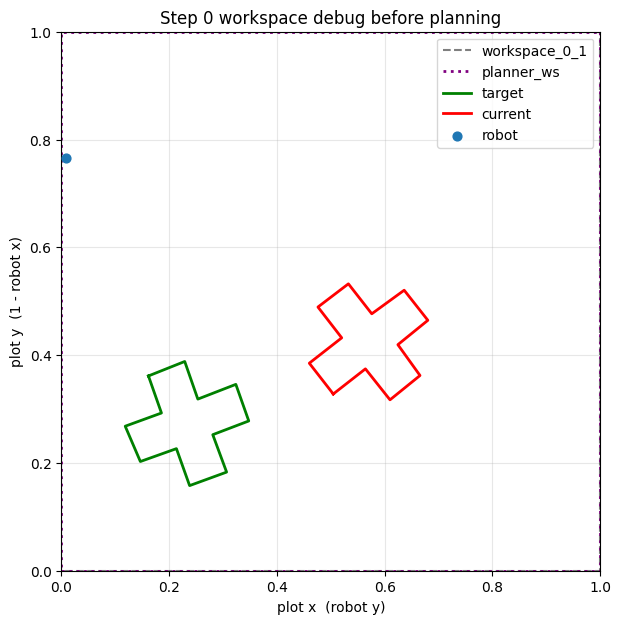

current_polygon_ws: [[     0.6721     0.49537]
 [    0.61497     0.53985]
 [    0.56792      0.4797]
 [    0.51078     0.52382]
 [    0.46773     0.46731]
 [    0.52332     0.42394]
 [    0.47958     0.36381]
 [     0.5354     0.31989]
 [    0.58062     0.37551]
 [    0.63781     0.33444]
 [    0.68292     0.39011]
 [    0.62547     0.43573]]
target_polygon_ws : [[    0.63862     0.83827]
 [    0.61179     0.77097]
 [     0.6816     0.74665]
 [    0.65424     0.67614]
 [    0.72215     0.65216]
 [     0.7476     0.71894]
 [    0.81703     0.69327]
 [    0.84209     0.76191]
 [    0.77351     0.78638]
 [    0.79739     0.85327]
 [    0.73189     0.88139]
 [    0.70739     0.81414]]
[PERF] brain.generate_face_candidates: 1.2 ms
[PERF] total_.simulate_push_stroke_normalized: avg 38.4 ms over 25 calls
[PERF] total_.simulate_push_stroke_normalized: avg 19.2 ms over 50 calls
[PERF] total_.simulate_push_stroke_normalized: avg 12.8 ms over 75 calls
[PERF] total_.simulate_push_stroke_normalized

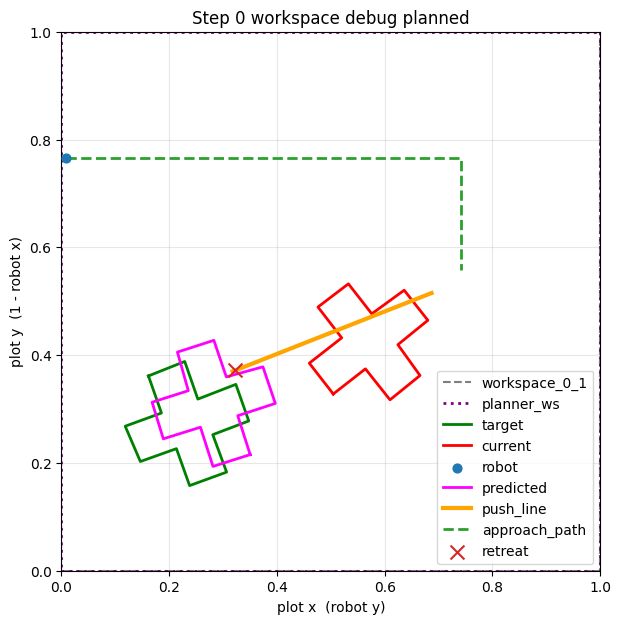

[Executor] Z축 고정(Task1) 모드로 Pushing Plan 실행!
  1) 장애물 우회하여 접근 (총 3개 웨이포인트)
  2) 푸시(Push) 진행 중... 목표점: (0.63, 0.68)
  3) 푸시 완료 후 후퇴 (Retreat)
execute_push ok: True
[POLYGON CONVERT] coord_space= undistorted_pixel_2d n= 12 x_range= (0.6417388165951572, 0.8672279350436527) y_range= (0.44942430420805646, 0.6752425736384629)
official_iou_after: 0.0
remaining_time_after_sec: 145.9
eval_status_after: {'status': 'running', 'time_elapsed': 34.1, 'time_remaining': 145.9, 'current_iou': 0.0}


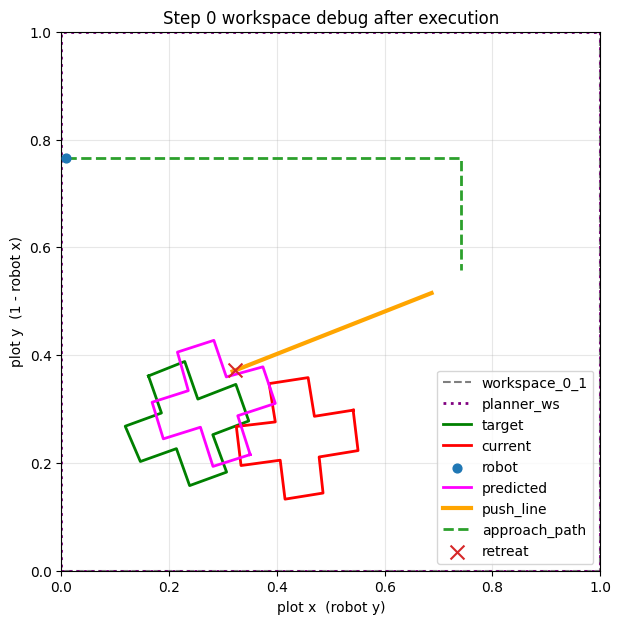

observed_pose_after: None
dtheta_obs: None
predicted: [0.68891498997105, 0.7172749537888672, -1.2168761146337923]
observed : None
dx_err: None
dy_err: None
dtheta_err: None
pos_err_norm: None
pred_disp: None
obs_disp : None
pred_along: None
obs_along : None
along_err : None
along_ratio (obs/pred): None
pred_lateral: None
obs_lateral : None
lateral_err : None
belief_update_ok: False
belief_update_error: None
belief_after: None
vote_box: None

--------------------------------------------------------------------------------
[STEP SUMMARY] step=0
--------------------------------------------------------------------------------
shape_type           : plus
current_pose         : None
target_pose          : None
robot_xy             : [0.23385714285714282, 0.9915714285714285]
num_feasible         : 8
attach_fail_count    : 8
execute_ok           : True
official_iou_before  : 0.0
official_iou_after   : 0.0
rgmc_iou             : None
predicted_next_pose  : [0.68891498997105, 0.7172749537888672,

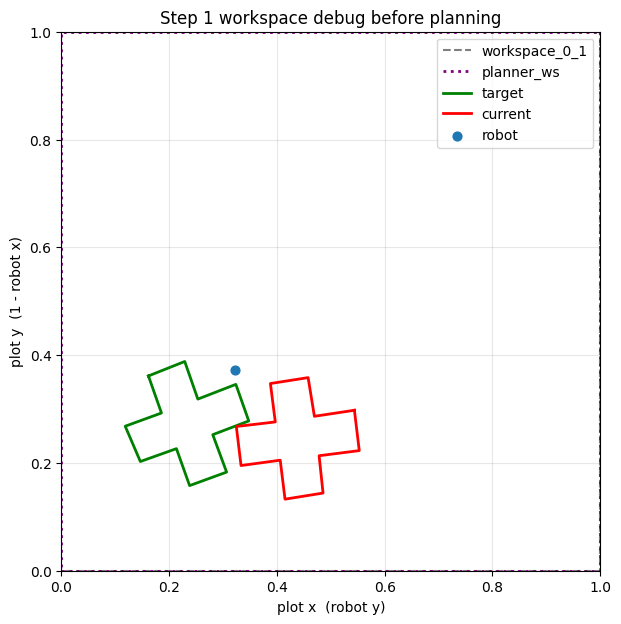

current_polygon_ws: [[    0.70228     0.45618]
 [    0.77716     0.44715]
 [    0.78666     0.52167]
 [    0.85591     0.51435]
 [    0.86723      0.5849]
 [    0.79493     0.59381]
 [    0.80485      0.6665]
 [    0.73242     0.67524]
 [    0.72396     0.60293]
 [     0.6527       0.612]
 [    0.64174     0.54205]
 [    0.71352      0.5304]]
target_polygon_ws : [[    0.63862     0.83827]
 [    0.61179     0.77097]
 [     0.6816     0.74665]
 [    0.65424     0.67614]
 [    0.72215     0.65216]
 [     0.7476     0.71894]
 [    0.81703     0.69327]
 [    0.84209     0.76191]
 [    0.77351     0.78638]
 [    0.79739     0.85327]
 [    0.73189     0.88139]
 [    0.70739     0.81414]]
[PERF] brain.generate_face_candidates: 1.2 ms
[PERF] total_.simulate_push_stroke_normalized: avg 5.5 ms over 175 calls
[PERF] total_.simulate_push_stroke_normalized: avg 4.8 ms over 200 calls
[PERF] total_.simulate_push_stroke_normalized: avg 4.3 ms over 225 calls
[PERF] total_.simulate_push_stroke_normalized

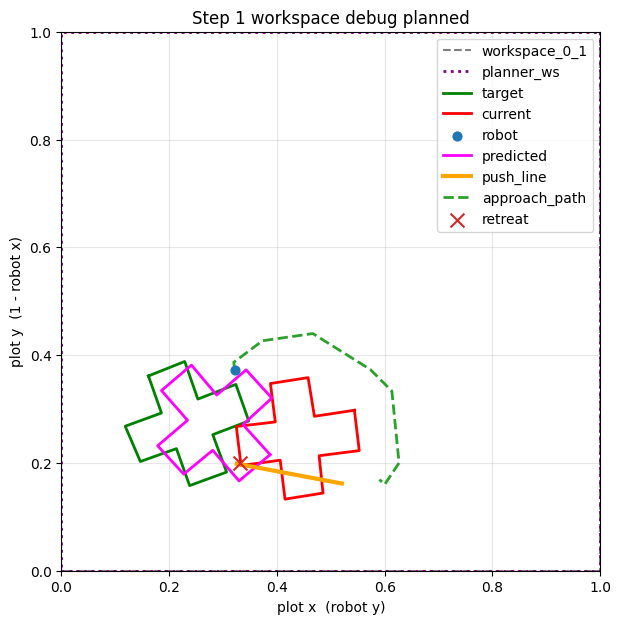

[Executor] Z축 고정(Task1) 모드로 Pushing Plan 실행!
  1) 장애물 우회하여 접근 (총 9개 웨이포인트)
  2) 푸시(Push) 진행 중... 목표점: (0.80, 0.67)
  3) 푸시 완료 후 후퇴 (Retreat)
execute_push ok: True
[POLYGON CONVERT] coord_space= undistorted_pixel_2d n= 12 x_range= (0.5872958375823312, 0.8046150521387355) y_range= (0.540274745531557, 0.759737295827277)
official_iou_after: 0.1
remaining_time_after_sec: 111.6
eval_status_after: {'status': 'running', 'time_elapsed': 68.4, 'time_remaining': 111.6, 'current_iou': 0.1}


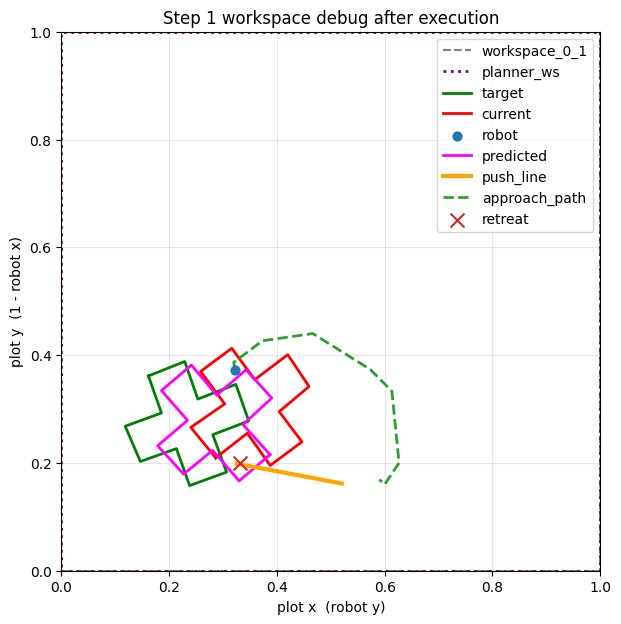

observed_pose_after: None
dtheta_obs: None
predicted: [0.7255317342942382, 0.7139766656116512, 0.9869030929935665]
observed : None
dx_err: None
dy_err: None
dtheta_err: None
pos_err_norm: None
pred_disp: None
obs_disp : None
pred_along: None
obs_along : None
along_err : None
along_ratio (obs/pred): None
pred_lateral: None
obs_lateral : None
lateral_err : None
belief_update_ok: False
belief_update_error: None
belief_after: None
vote_box: None

--------------------------------------------------------------------------------
[STEP SUMMARY] step=1
--------------------------------------------------------------------------------
shape_type           : plus
current_pose         : None
target_pose          : None
robot_xy             : [0.6273571428571428, 0.6780714285714287]
num_feasible         : 6
attach_fail_count    : 10
execute_ok           : True
official_iou_before  : 0.0
official_iou_after   : 0.1
rgmc_iou             : None
predicted_next_pose  : [0.7255317342942382, 0.71397666561165

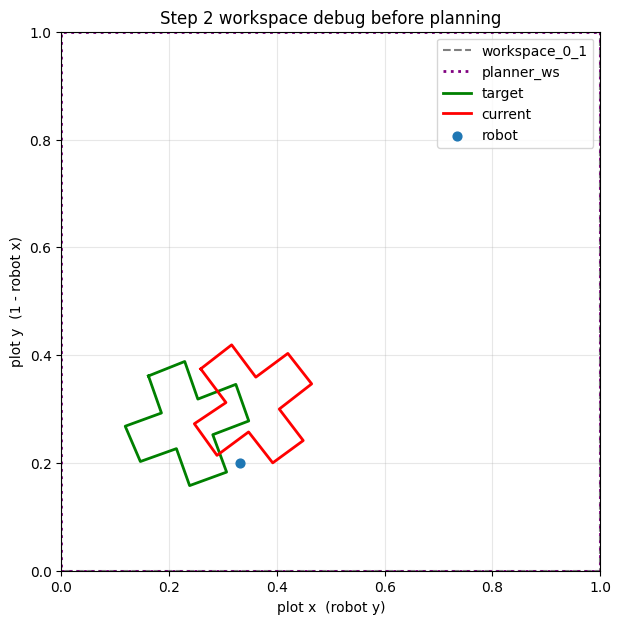

current_polygon_ws: [[    0.62551      0.7413]
 [    0.58092     0.68391]
 [    0.64087     0.63908]
 [    0.59684     0.57966]
 [    0.65334     0.53542]
 [    0.70008      0.5956]
 [     0.7585     0.55109]
 [    0.79991     0.60769]
 [    0.74253     0.65249]
 [      0.786      0.7111]
 [    0.72734     0.75315]
 [    0.68802     0.69445]]
target_polygon_ws : [[    0.63862     0.83827]
 [    0.61179     0.77097]
 [     0.6816     0.74665]
 [    0.65424     0.67614]
 [    0.72215     0.65216]
 [     0.7476     0.71894]
 [    0.81703     0.69327]
 [    0.84209     0.76191]
 [    0.77351     0.78638]
 [    0.79739     0.85327]
 [    0.73189     0.88139]
 [    0.70739     0.81414]]
[PERF] brain.generate_face_candidates: 1.1 ms
[PERF] total_.simulate_push_stroke_normalized: avg 3.0 ms over 325 calls
[PERF] total_.simulate_push_stroke_normalized: avg 2.8 ms over 350 calls
[PERF] total_.simulate_push_stroke_normalized: avg 2.6 ms over 375 calls
[PERF] total_.simulate_push_stroke_normalized

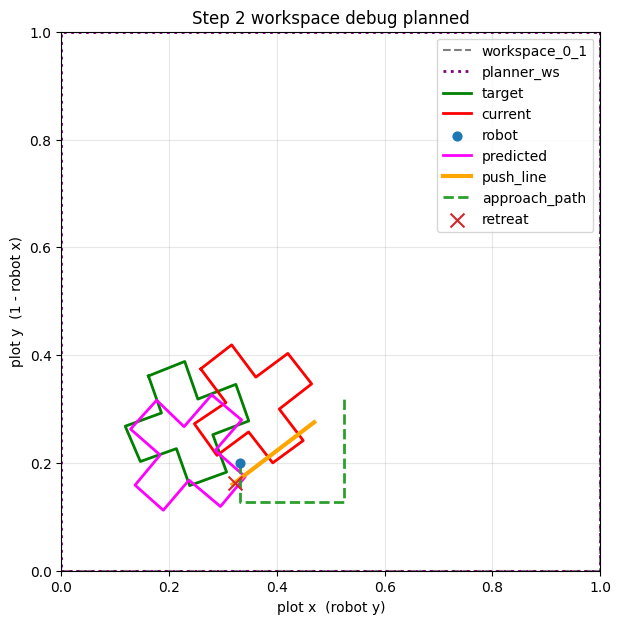

[Executor] Z축 고정(Task1) 모드로 Pushing Plan 실행!
  1) 장애물 우회하여 접근 (총 5개 웨이포인트)
  2) 푸시(Push) 진행 중... 목표점: (0.84, 0.68)
  3) 푸시 완료 후 후퇴 (Retreat)
execute_push ok: True
[POLYGON CONVERT] coord_space= undistorted_pixel_2d n= 12 x_range= (0.6268499536849871, 0.8584339883284535) y_range= (0.6140663862326111, 0.8438295945899112)
official_iou_after: 0.5
remaining_time_after_sec: 81.5
eval_status_after: {'status': 'running', 'time_elapsed': 98.5, 'time_remaining': 81.5, 'current_iou': 0.5}


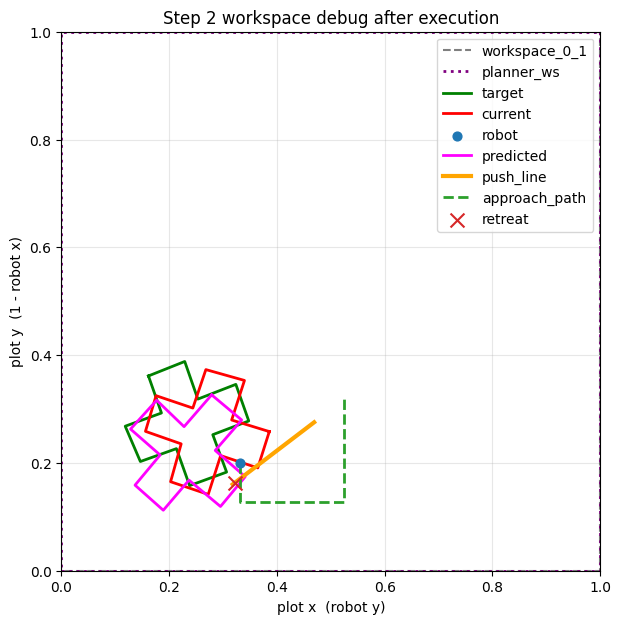

observed_pose_after: None
dtheta_obs: None
predicted: [0.7814117342142264, 0.7643572699750988, 1.3574299839144786]
observed : None
dx_err: None
dy_err: None
dtheta_err: None
pos_err_norm: None
pred_disp: None
obs_disp : None
pred_along: None
obs_along : None
along_err : None
along_ratio (obs/pred): None
pred_lateral: None
obs_lateral : None
lateral_err : None
belief_update_ok: False
belief_update_error: None
belief_after: None
vote_box: None

--------------------------------------------------------------------------------
[STEP SUMMARY] step=2
--------------------------------------------------------------------------------
shape_type           : plus
current_pose         : None
target_pose          : None
robot_xy             : [0.801, 0.6691428571428572]
num_feasible         : 15
attach_fail_count    : 1
execute_ok           : True
official_iou_before  : 0.1
official_iou_after   : 0.5
rgmc_iou             : None
predicted_next_pose  : [0.7814117342142264, 0.7643572699750988, 1.3574299

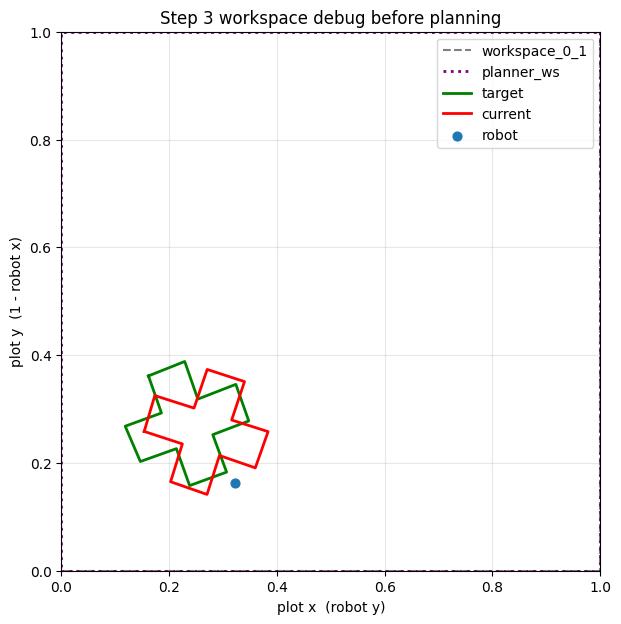

current_polygon_ws: [[    0.74159     0.84613]
 [    0.67505     0.82649]
 [    0.69827     0.75368]
 [    0.62658     0.72934]
 [    0.64913     0.66005]
 [    0.72038     0.68389]
 [     0.7419     0.61633]
 [    0.80918     0.64003]
 [    0.78626     0.70656]
 [    0.85844     0.72963]
 [     0.8349      0.7972]
 [    0.76475     0.77534]]
target_polygon_ws : [[    0.63862     0.83827]
 [    0.61179     0.77097]
 [     0.6816     0.74665]
 [    0.65424     0.67614]
 [    0.72215     0.65216]
 [     0.7476     0.71894]
 [    0.81703     0.69327]
 [    0.84209     0.76191]
 [    0.77351     0.78638]
 [    0.79739     0.85327]
 [    0.73189     0.88139]
 [    0.70739     0.81414]]
[PERF] brain.generate_face_candidates: 1.7 ms
[PERF] total_.simulate_push_stroke_normalized: avg 2.0 ms over 475 calls
[PERF] total_.simulate_push_stroke_normalized: avg 1.9 ms over 500 calls
[PERF] total_.simulate_push_stroke_normalized: avg 1.8 ms over 525 calls
[PERF] total_.simulate_push_stroke_normalized

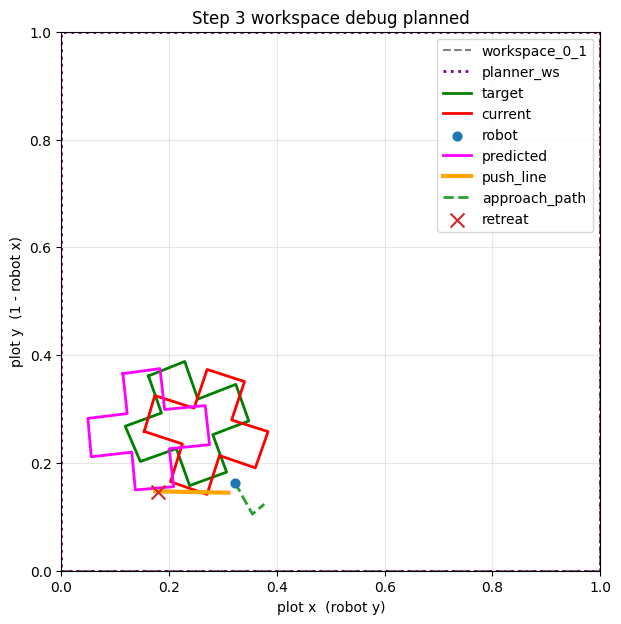

[Executor] Z축 고정(Task1) 모드로 Pushing Plan 실행!
  1) 장애물 우회하여 접근 (총 3개 웨이포인트)
  2) 푸시(Push) 진행 중... 목표점: (0.85, 0.83)
  3) 푸시 완료 후 후퇴 (Retreat)
execute_push ok: True
[POLYGON CONVERT] coord_space= undistorted_pixel_2d n= 12 x_range= (0.619987568969052, 0.8323097514330057) y_range= (0.6671869542397693, 0.8834219960947095)
official_iou_after: 0.6
remaining_time_after_sec: 63.1
eval_status_after: {'status': 'running', 'time_elapsed': 116.9, 'time_remaining': 63.1, 'current_iou': 0.6}


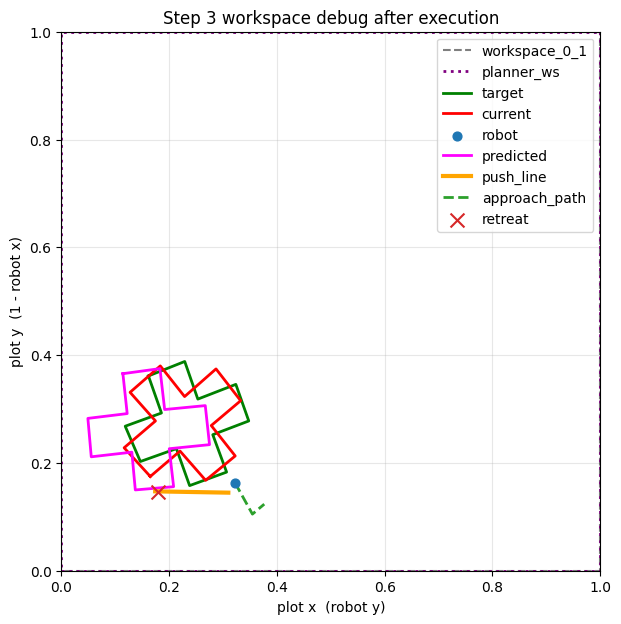

observed_pose_after: None
dtheta_obs: None
predicted: [0.7397008314806525, 0.8382924522989592, 1.1475550006006294]
observed : None
dx_err: None
dy_err: None
dtheta_err: None
pos_err_norm: None
pred_disp: None
obs_disp : None
pred_along: None
obs_along : None
along_err : None
along_ratio (obs/pred): None
pred_lateral: None
obs_lateral : None
lateral_err : None
belief_update_ok: False
belief_update_error: None
belief_after: None
vote_box: None

--------------------------------------------------------------------------------
[STEP SUMMARY] step=3
--------------------------------------------------------------------------------
shape_type           : plus
current_pose         : None
target_pose          : None
robot_xy             : [0.8367142857142857, 0.6777857142857143]
num_feasible         : 16
attach_fail_count    : 0
execute_ok           : True
official_iou_before  : 0.5
official_iou_after   : 0.6
rgmc_iou             : None
predicted_next_pose  : [0.7397008314806525, 0.83829245229895

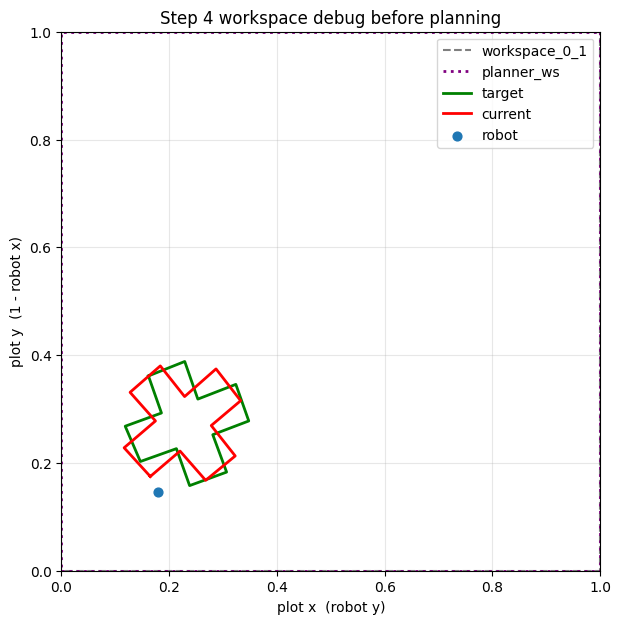

current_polygon_ws: [[    0.82513     0.83486]
 [     0.7719     0.88342]
 [    0.72215     0.82522]
 [      0.669     0.87237]
 [    0.61999     0.81629]
 [    0.67692     0.77121]
 [    0.62556     0.71292]
 [    0.68455     0.66719]
 [    0.73064     0.72178]
 [    0.78705     0.67728]
 [    0.83231     0.73213]
 [    0.77797     0.77971]]
target_polygon_ws : [[    0.63862     0.83827]
 [    0.61179     0.77097]
 [     0.6816     0.74665]
 [    0.65424     0.67614]
 [    0.72215     0.65216]
 [     0.7476     0.71894]
 [    0.81703     0.69327]
 [    0.84209     0.76191]
 [    0.77351     0.78638]
 [    0.79739     0.85327]
 [    0.73189     0.88139]
 [    0.70739     0.81414]]
[PERF] brain.generate_face_candidates: 1.3 ms
[PERF] total_.simulate_push_stroke_normalized: avg 1.5 ms over 625 calls
[PERF] total_.simulate_push_stroke_normalized: avg 1.5 ms over 650 calls
[PERF] total_.simulate_push_stroke_normalized: avg 1.4 ms over 675 calls
[PERF] total_.simulate_push_stroke_normalized

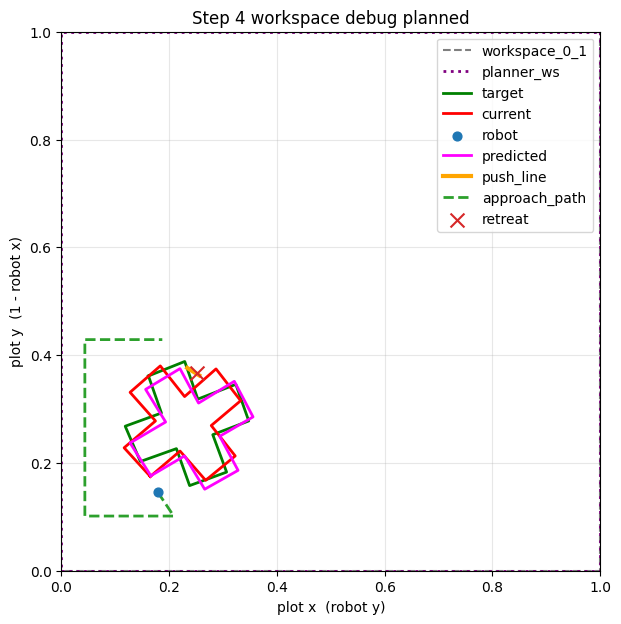

[Executor] Z축 고정(Task1) 모드로 Pushing Plan 실행!
  1) 장애물 우회하여 접근 (총 5개 웨이포인트)
  2) 푸시(Push) 진행 중... 목표점: (0.64, 0.74)
  3) 푸시 완료 후 후퇴 (Retreat)
execute_push ok: True
[POLYGON CONVERT] coord_space= undistorted_pixel_2d n= 12 x_range= (0.6432653449918356, 0.8584359856704473) y_range= (0.6636229331654826, 0.8788928468406296)
official_iou_after: 0.6
remaining_time_after_sec: 41.0
eval_status_after: {'status': 'running', 'time_elapsed': 139.0, 'time_remaining': 41.0, 'current_iou': 0.6}


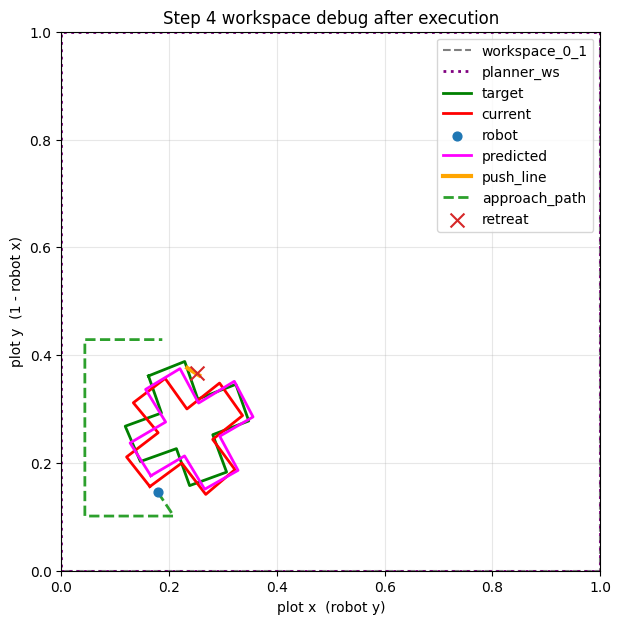

observed_pose_after: None
dtheta_obs: None
predicted: [0.7373584955373893, 0.7569546549900921, 0.1752340790810667]
observed : None
dx_err: None
dy_err: None
dtheta_err: None
pos_err_norm: None
pred_disp: None
obs_disp : None
pred_along: None
obs_along : None
along_err : None
along_ratio (obs/pred): None
pred_lateral: None
obs_lateral : None
lateral_err : None
belief_update_ok: False
belief_update_error: None
belief_after: None
vote_box: None

--------------------------------------------------------------------------------
[STEP SUMMARY] step=4
--------------------------------------------------------------------------------
shape_type           : plus
current_pose         : None
target_pose          : None
robot_xy             : [0.8542142857142857, 0.821]
num_feasible         : 14
attach_fail_count    : 2
execute_ok           : True
official_iou_before  : 0.6
official_iou_after   : 0.6
rgmc_iou             : None
predicted_next_pose  : [0.7373584955373893, 0.7569546549900921, 0.1752340

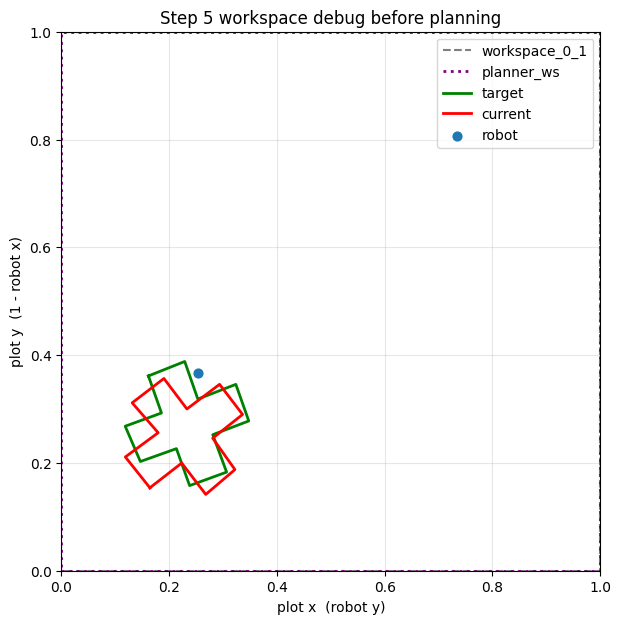

current_polygon_ws: [[    0.84613     0.83558]
 [    0.78896     0.88115]
 [    0.74399     0.82021]
 [    0.68852     0.86849]
 [    0.64333     0.80958]
 [    0.69991     0.76689]
 [    0.65421      0.7063]
 [    0.71009     0.66366]
 [    0.75415     0.71904]
 [    0.81237      0.6778]
 [    0.85844     0.73193]
 [    0.80022     0.77655]]
target_polygon_ws : [[    0.63862     0.83827]
 [    0.61179     0.77097]
 [     0.6816     0.74665]
 [    0.65424     0.67614]
 [    0.72215     0.65216]
 [     0.7476     0.71894]
 [    0.81703     0.69327]
 [    0.84209     0.76191]
 [    0.77351     0.78638]
 [    0.79739     0.85327]
 [    0.73189     0.88139]
 [    0.70739     0.81414]]
[PERF] brain.generate_face_candidates: 1.4 ms
[PERF] total_.simulate_push_stroke_normalized: avg 1.2 ms over 800 calls
[PERF] total_.simulate_push_stroke_normalized: avg 1.2 ms over 825 calls
[PERF] total_.simulate_push_stroke_normalized: avg 1.1 ms over 850 calls
[PERF] total_.simulate_push_stroke_normalized

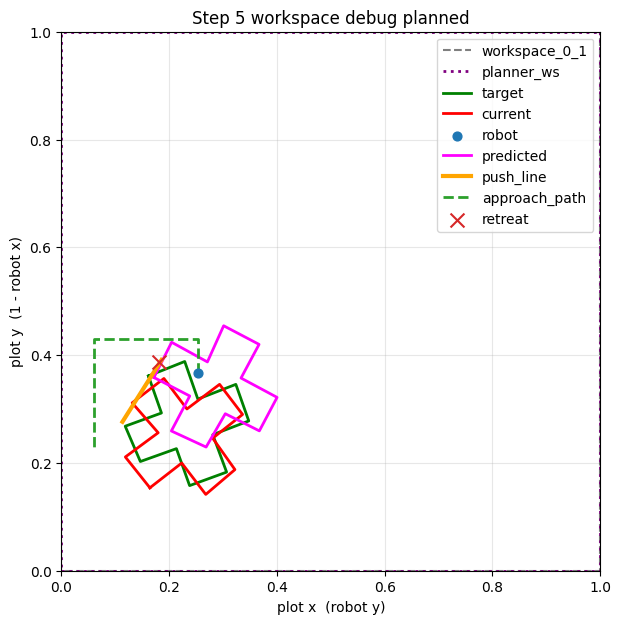

[Executor] Z축 고정(Task1) 모드로 Pushing Plan 실행!
  1) 장애물 우회하여 접근 (총 5개 웨이포인트)
  2) 푸시(Push) 진행 중... 목표점: (0.61, 0.81)
  3) 푸시 완료 후 후퇴 (Retreat)
execute_push ok: True
[POLYGON CONVERT] coord_space= undistorted_pixel_2d n= 12 x_range= (0.6027285868980645, 0.8303089124002883) y_range= (0.6208413391832382, 0.8475982120661649)
official_iou_after: 0.5
remaining_time_after_sec: 18.8
eval_status_after: {'status': 'running', 'time_elapsed': 161.2, 'time_remaining': 18.8, 'current_iou': 0.5}


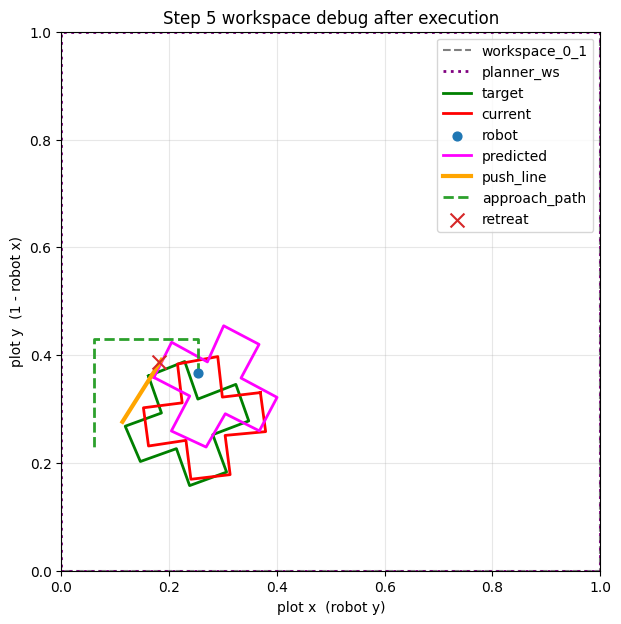

observed_pose_after: None
dtheta_obs: None
predicted: [0.6593031479925808, 0.7142495159830279, 1.1383618890949965]
observed : None
dx_err: None
dy_err: None
dtheta_err: None
pos_err_norm: None
pred_disp: None
obs_disp : None
pred_along: None
obs_along : None
along_err : None
along_ratio (obs/pred): None
pred_lateral: None
obs_lateral : None
lateral_err : None
belief_update_ok: False
belief_update_error: None
belief_after: None
vote_box: None

--------------------------------------------------------------------------------
[STEP SUMMARY] step=5
--------------------------------------------------------------------------------
shape_type           : plus
current_pose         : None
target_pose          : None
robot_xy             : [0.6339999999999999, 0.7470714285714286]
num_feasible         : 12
attach_fail_count    : 4
execute_ok           : True
official_iou_before  : 0.6
official_iou_after   : 0.5
rgmc_iou             : None
predicted_next_pose  : [0.6593031479925808, 0.71424951598302

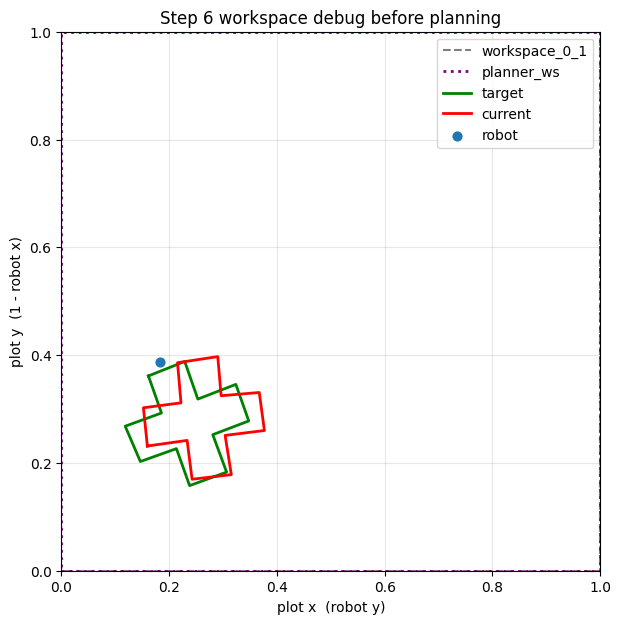

current_polygon_ws: [[    0.76863     0.84029]
 [     0.6977      0.8476]
 [    0.68851     0.77786]
 [     0.6141     0.78436]
 [    0.60273     0.70969]
 [    0.67534     0.70341]
 [    0.66933     0.63271]
 [    0.73983     0.62313]
 [    0.74895     0.69603]
 [     0.8217     0.68451]
 [    0.83029     0.75734]
 [    0.75824     0.76651]]
target_polygon_ws : [[    0.63862     0.83827]
 [    0.61179     0.77097]
 [     0.6816     0.74665]
 [    0.65424     0.67614]
 [    0.72215     0.65216]
 [     0.7476     0.71894]
 [    0.81703     0.69327]
 [    0.84209     0.76191]
 [    0.77351     0.78638]
 [    0.79739     0.85327]
 [    0.73189     0.88139]
 [    0.70739     0.81414]]
[PERF] brain.generate_face_candidates: 1.2 ms
[PERF] total_.simulate_push_stroke_normalized: avg 1.0 ms over 950 calls
[PERF] total_.simulate_push_stroke_normalized: avg 1.0 ms over 975 calls
[PERF] total_.simulate_push_stroke_normalized: avg 1.0 ms over 1000 calls
[PERF] total_.simulate_push_stroke_normalize

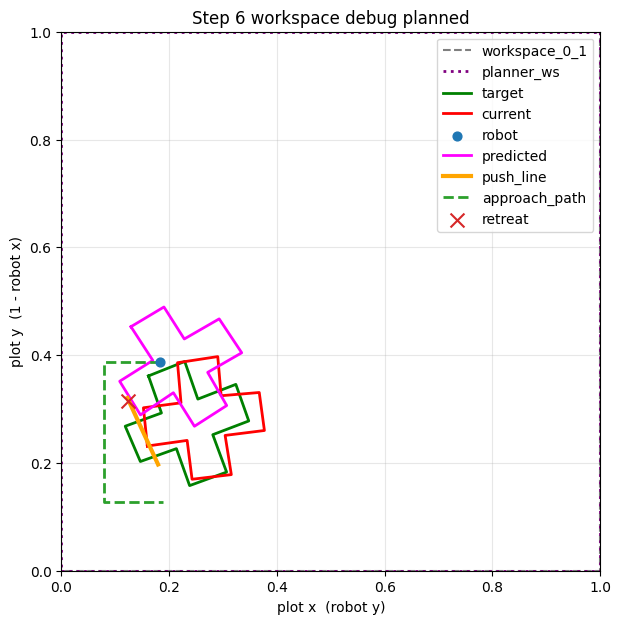

[Executor] Z축 고정(Task1) 모드로 Pushing Plan 실행!
  1) 장애물 우회하여 접근 (총 5개 웨이포인트)
  2) 푸시(Push) 진행 중... 목표점: (0.68, 0.88)
  3) 푸시 완료 후 후퇴 (Retreat)
execute_push ok: True
eval_object failed: {'detail': 'No active evaluation run'}
eval_status failed: {'detail': 'No active evaluation run'}
official_iou_after: None
remaining_time_after_sec: None
eval_status_after: None
[WARN] get_state_after failed: KeyError('state')


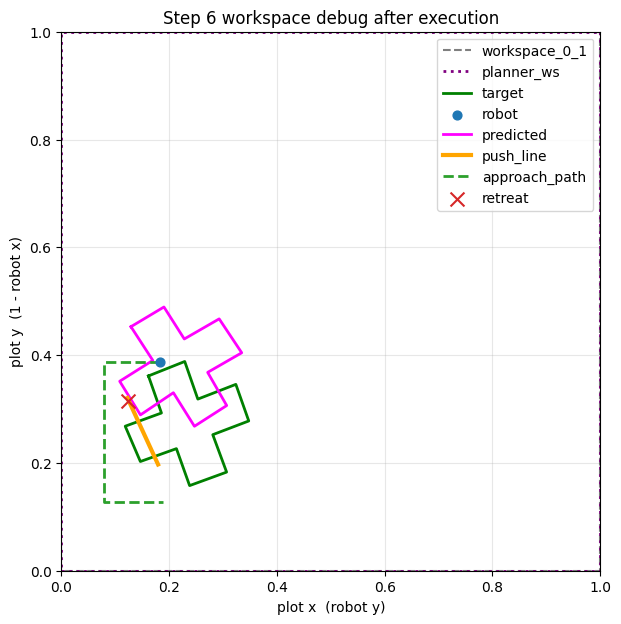

observed_pose_after: None
dtheta_obs: None
predicted: [0.6206522939119944, 0.7797827535623397, 1.1350227976754876]
observed : None
dx_err: None
dy_err: None
dtheta_err: None
pos_err_norm: None
pred_disp: None
obs_disp : None
pred_along: None
obs_along : None
along_err : None
along_ratio (obs/pred): None
pred_lateral: None
obs_lateral : None
lateral_err : None
belief_update_ok: False
belief_update_error: None
belief_after: None
vote_box: None

--------------------------------------------------------------------------------
[STEP SUMMARY] step=6
--------------------------------------------------------------------------------
shape_type           : plus
current_pose         : None
target_pose          : None
robot_xy             : [0.6122142857142857, 0.8174285714285714]
num_feasible         : 1
attach_fail_count    : 15
execute_ok           : True
official_iou_before  : 0.5
official_iou_after   : None
rgmc_iou             : None
predicted_next_pose  : [0.6206522939119944, 0.7797827535623

AttributeError: 'NoneType' object has no attribute 'get'

In [19]:

# =========================================================
# Runtime guard before Task1 loop
# 원인 방지:
# - Cell 1을 다시 실행하면 planner/brain/executor가 None으로 초기화됨.
# - 그래서 Cell 3 진입 직전에 반드시 복구/검증한다.
# =========================================================
def _ensure_runtime_ready_before_task1_loop():
    global mapper, planner, brain, executor

    missing = (
        ("mapper" not in globals()) or mapper is None or
        ("planner" not in globals()) or planner is None or
        ("brain" not in globals()) or brain is None or
        ("executor" not in globals()) or executor is None
    )

    if missing:
        print("[RUNTIME GUARD] mapper/planner/brain/executor not ready.")
        print("[RUNTIME GUARD] mapper :", None if "mapper" not in globals() else type(mapper))
        print("[RUNTIME GUARD] planner:", None if "planner" not in globals() else type(planner))
        print("[RUNTIME GUARD] brain  :", None if "brain" not in globals() else type(brain))
        print("[RUNTIME GUARD] executor:", None if "executor" not in globals() else type(executor))

        if ("COMPETITION_MODE" in globals()) and COMPETITION_MODE:
            # competition mode에서는 competition_start를 여기서 몰래 다시 부르면 안 됨.
            if ("mapper" not in globals()) or mapper is None:
                raise RuntimeError(
                    "COMPETITION_MODE=True인데 mapper가 없습니다. "
                    "Cell 2에서 competition_start('task1') -> _set_competition_robot_map_context(...) -> finalize_runtime_context()를 먼저 실행하세요."
                )
            finalize_runtime_context()
        else:
            # fixed robot mode에서는 Cell 2를 빼먹었거나 Cell 1 재실행 후 Cell 3을 누른 경우 자동 복구.
            try:
                robot.eval_start()
                print("[RUNTIME GUARD] robot.eval_start() ok")
            except Exception as e:
                print("[RUNTIME GUARD] robot.eval_start() skipped/failed:", repr(e))

            if ("mapper" not in globals()) or mapper is None:
                _set_fixed_robot_map_context()

            finalize_runtime_context()

    if brain is None:
        raise RuntimeError(
            "brain is None right before planning. "
            "This means Cell 1 reset brain after Cell 2, or finalize_runtime_context() did not run."
        )
    if planner is None:
        raise RuntimeError("planner is None right before planning.")
    if executor is None:
        raise RuntimeError("executor is None right before planning.")
    if not hasattr(brain, "generate_candidate_bundle"):
        raise RuntimeError("brain object has no generate_candidate_bundle(). Wrong/old brain imported.")
    if not hasattr(brain, "get_best_plan_polygon"):
        raise RuntimeError("brain object has no get_best_plan_polygon(). Wrong/old brain imported.")

    print("[RUNTIME GUARD] OK:", type(brain), "planner:", type(planner), "executor:", type(executor))

_ensure_runtime_ready_before_task1_loop()


# =========================================================
#  target pose
# =========================================================

TARGET_DATA = robot.eval_target()
pretty_print(TARGET_DATA, "eval_target")
TARGET_SHAPE = TARGET_DATA.get("target_object") or "unknown"

# 기존 원/네모/T는 기존 pose/template 물리 planner 유지.
# surprise/unknown shape는 polygon에서 즉석으로 mass/I/COM을 계산하는 dynamic physics planner 사용.
KNOWN_SHAPES = ("circle", "square", "t")
TARGET_IS_KNOWN_SHAPE = TARGET_SHAPE in KNOWN_SHAPES

if TARGET_IS_KNOWN_SHAPE:
    TARGET_POSE = calculate_pose(TARGET_DATA, TARGET_SHAPE, mapper)
else:
    TARGET_POSE = None

print("TARGET_SHAPE:", TARGET_SHAPE)
print("TARGET_IS_KNOWN_SHAPE:", TARGET_IS_KNOWN_SHAPE)
print("KNOWN_SHAPES:", KNOWN_SHAPES)
print("TARGET_POSE (workspace pose from eval_target):", TARGET_POSE)


# =========================
# Multi-step Task1 push loop
# =========================
# =========================
# Multi-step Task1 push loop
# =========================
MAX_STEPS = 20
EXECUTE_PUSH = True
SLEEP_AFTER_PUSH = 1.0

# 남은 시간이 끝나면 현재 main loop를 종료한다.
# - RUN ALL로 실행 중이면 이 셀이 끝난 뒤 다음 셀로 넘어간다.
# - 단일 셀 실행 중이면 이 셀만 정상 종료된다.
STOP_WHEN_TIME_OVER = True

# eval_status["status"]가 running이 아니면 즉시 종료한다.
# 예: success, done, timeout, finished, failed 등 서버가 run 종료 상태를 주면 다음 step을 시작하지 않음.
STOP_WHEN_EVAL_STATUS_NOT_RUNNING = True

# 0.0이면 진짜 남은 시간이 0초 이하일 때만 종료.
# 너무 촉박할 때 다음 push를 시작하지 않으려면 5~10초 정도로 올리면 됨.
MIN_REMAINING_TIME_TO_START_STEP_SEC = 0.0

# 공식 평가 기준 IoU threshold
if TARGET_SHAPE == 't':
    SUCCESS_IOU = task1_config.IOU_SUCCESS_T   # defined in config.py 
elif TARGET_SHAPE == 'square':
    SUCCESS_IOU = task1_config.IOU_SUCCESS_S   # defined in config.py 
elif TARGET_SHAPE == 'circle':
    SUCCESS_IOU = task1_config.IOU_SUCCESS_C   # defined in config.py 
else:
    SUCCESS_IOU = getattr(task1_config, "UNKNOWN_IOU_SUCCESS", 0.8)

DEBUG_PLAN_FAIL_DUMP = True

print("[STOP CONFIG] SUCCESS_IOU:", SUCCESS_IOU)
print("[STOP CONFIG] MIN_REMAINING_TIME_TO_START_STEP_SEC:", MIN_REMAINING_TIME_TO_START_STEP_SEC)
print("[STOP CONFIG] STOP_WHEN_EVAL_STATUS_NOT_RUNNING:", STOP_WHEN_EVAL_STATUS_NOT_RUNNING)

STATE_STABLE_MAX_TRIES = 8
STATE_STABLE_INTERVAL = 0.20
STATE_STABLE_TOL = 0.01
STATE_STABLE_REQUIRED_CONSECUTIVE = 2

history = []

def wrap_angle_rad(angle):
    return math.atan2(math.sin(angle), math.cos(angle))


#===================김보형==============================================================================


# =========================================================
# Dataset logging for learned pushing dynamics / teacher data
# =========================================================
# 목적:
# 1) 실제 로봇 실행 데이터: physics_next_pose와 real_next_pose 차이를 학습
# 2) teacher 후보 데이터: 현재 planner가 만든 후보/점수/선택 결과를 저장해서 BC/AWAC에 사용


if DATASET_LOGS == True:
    DATASET_DIR.mkdir(parents=True, exist_ok=True)
    RUN_ID = time.strftime("task1_%Y%m%d_%H%M%S")
    REAL_DYNAMICS_JSONL = DATASET_DIR / "task1_physics_dynamics.jsonl"
    TEACHER_CANDIDATES_JSONL = DATASET_DIR / "task1_teacher_candidates.jsonl"
    
    DATASET_CANDIDATE_TOPN = 32
    # 후보를 너무 많이 저장하면 파일이 커지므로 상위 N개만 저장한다.
    # None으로 두면 전체 저장.
else:
    REAL_DYNAMICS_JSONL = None
    TEACHER_CANDIDATES_JSONL = None


def json_safe(obj):
    """numpy / Path / dict / list가 섞인 값을 JSON 저장 가능한 형태로 변환."""
    if obj is None:
        return None
    if isinstance(obj, (str, bool, int, float)):
        return obj
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.astype(float).tolist()
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (list, tuple)):
        return [json_safe(v) for v in obj]
    if isinstance(obj, dict):
        return {str(k): json_safe(v) for k, v in obj.items()}
    try:
        return float(obj)
    except Exception:
        return str(obj)


def append_jsonl(path, record):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(json_safe(record), ensure_ascii=False) + "\n")


def angle_diff_rad(a, b):
    if a is None or b is None:
        return None
    return math.atan2(math.sin(float(a) - float(b)), math.cos(float(a) - float(b)))


def pose_delta(to_pose, from_pose):
    if to_pose is None or from_pose is None:
        return None
    return [
        float(to_pose[0] - from_pose[0]),
        float(to_pose[1] - from_pose[1]),
        float(angle_diff_rad(to_pose[2], from_pose[2])),
    ]


def candidate_to_record(candidate):
    if candidate is None:
        return None
    return {
        "index": candidate.get("index"),
        "face_idx": candidate.get("face_idx"),
        "ratio": candidate.get("ratio"),
        "action_type": candidate.get("action_type"),
        "stroke_len": candidate.get("stroke_len"),
        "start": candidate.get("start"),
        "end": candidate.get("end"),
        "n_hat": candidate.get("n_hat"),
        "t_hat": candidate.get("t_hat"),
    }


def motion_to_record(motion):
    if motion is None:
        return None
    return {
        "approach_path": motion.get("approach_path"),
        "approach_length": motion.get("approach_length"),
        "approach_xy": motion.get("approach_xy"),
        "push_start": motion.get("push_start"),
        "push_end": motion.get("push_end"),
        "retreat_xy": motion.get("retreat_xy"),
        "approach_waypoint_count": len(motion.get("approach_path", [])),
    }


def scored_candidate_to_record(item, candidate_data=None):
    """scored_candidate_actions item을 학습용 후보 record로 변환."""
    if item is None:
        return None

    cand = item.get("candidate", {})
    idx = cand.get("index")
    feasible_item = None
    if candidate_data is not None:
        feasible_item = candidate_data.get("feasible", {}).get(idx)

    motion = None
    path_cost = None
    final_score = None
    if feasible_item is not None:
        motion = feasible_item.get("motion")
        try:
            push_len = float(np.linalg.norm(np.asarray(cand.get("end"), dtype=float) - np.asarray(cand.get("start"), dtype=float)))
            path_cost = float(motion.get("approach_length", 0.0) + push_len)
            final_score = float(item.get("align", 0.0) + item.get("progress", 0.0) - task1_config.DIRECT_PATH_PENALTY * path_cost)
        except Exception:
            path_cost = None
            final_score = None

    return {
        "candidate": candidate_to_record(cand),
        "physics_next_pose": item.get("next_pose"),
        "current_shape_err": item.get("current_shape_err"),
        "next_shape_err": item.get("next_shape_err"),
        "progress": item.get("progress"),
        "align": item.get("align"),
        "cheap_score": item.get("cheap_score"),
        "feasible": feasible_item is not None,
        "path_cost": path_cost,
        "final_score": final_score,
        "motion": motion_to_record(motion),
    }


def build_teacher_candidates_record(
    step_idx,
    shape_type,
    current_pose,
    target_pose,
    robot_xy,
    candidate_data,
    plan,
    official_iou_before=None,
    official_iou_after=None,
):
    """planner가 만든 후보/순위/선택 결과를 저장. BC/AWAC teacher 데이터용."""
    if candidate_data is None:
        return None

    scored_all = list(candidate_data.get("scored_candidate_actions", []))
    if DATASET_CANDIDATE_TOPN is not None:
        scored_all = scored_all[:int(DATASET_CANDIDATE_TOPN)]

    selected_idx = None
    if plan is not None and plan.get("candidate") is not None:
        selected_idx = plan["candidate"].get("index")

    ranked = []
    for rank, item in enumerate(scored_all, start=1):
        rec = scored_candidate_to_record(item, candidate_data=candidate_data)
        if rec is None:
            continue
        cand_idx = None if rec.get("candidate") is None else rec["candidate"].get("index")
        rec["rank"] = rank
        rec["selected"] = (cand_idx == selected_idx)
        ranked.append(rec)

    return {
        "record_type": "teacher_candidates_step",
        "run_id": RUN_ID,
        "step_idx": int(step_idx),
        "shape_type": shape_type,
        "current_pose": current_pose,
        "target_pose": target_pose,
        "robot_xy": robot_xy,
        "local_target": candidate_data.get("local_target"),
        "global_shape_err": candidate_data.get("global_shape_err"),
        "current_local_err": candidate_data.get("current_local_err"),
        "chosen_lookahead": candidate_data.get("chosen_lookahead"),
        "base_stroke": candidate_data.get("base_stroke"),
        "allowed_strokes": candidate_data.get("allowed_strokes"),
        "candidate_counts": {
            "filtered_faces": len(candidate_data.get("filtered_faces", [])),
            "candidate_actions": len(candidate_data.get("candidate_actions", [])),
            "scored_candidate_actions": len(candidate_data.get("scored_candidate_actions", [])),
            "shortlisted_actions": len(candidate_data.get("shortlisted_actions", [])),
            "feasible": len(candidate_data.get("feasible", {})),
            "attach_attempt_count": candidate_data.get("attach_attempt_count"),
            "attach_fail_count": candidate_data.get("attach_fail_count"),
            "exhaustive_attach_used": candidate_data.get("exhaustive_attach_used"),
        },
        "selected_action": None if plan is None else candidate_to_record(plan.get("candidate")),
        "selected_physics_next_pose": None if plan is None else plan.get("next_pose"),
        "selected_score_terms": None if plan is None else {
            "score": plan.get("score"),
            "path_cost": plan.get("path_cost"),
            "progress": plan.get("progress"),
            "align": plan.get("align"),
            "next_shape_err": plan.get("next_shape_err"),
            "current_shape_err": plan.get("current_shape_err"),
        },
        "official_iou_before": official_iou_before,
        "official_iou_after": official_iou_after,
        "ranked_candidates_topn": ranked,
    }


def build_real_push_dynamics_record(
    step_idx,
    shape_type,
    current_pose,
    target_pose,
    robot_xy,
    robot_xy_after,
    candidate_data,
    plan,
    execute_ok,
    observed_pose_after,
    official_iou_before=None,
    official_iou_after=None,
    rgmc_iou=None,
    belief_before=None,
    belief_after=None,
    timing_entry=None,
):
    """실제 실행 1스텝을 learned dynamics 학습용으로 저장."""
    if plan is None:
        return None

    physics_next = plan.get("next_pose")
    valid = bool(execute_ok and observed_pose_after is not None and current_pose is not None and physics_next is not None)

    iou_delta = None
    if official_iou_before is not None and official_iou_after is not None:
        try:
            iou_delta = float(official_iou_after) - float(official_iou_before)
        except Exception:
            iou_delta = None

    rec = {
        "record_type": "real_push_dynamics_step",
        "run_id": RUN_ID,
        "step_idx": int(step_idx),
        "valid_for_dynamics": valid,
        "shape_type": shape_type,
        "current_pose": current_pose,
        "target_pose": target_pose,
        "local_target": None if candidate_data is None else candidate_data.get("local_target"),
        "global_shape_err": None if candidate_data is None else candidate_data.get("global_shape_err"),
        "current_local_err": None if candidate_data is None else candidate_data.get("current_local_err"),
        "base_stroke": None if candidate_data is None else candidate_data.get("base_stroke"),
        "allowed_strokes": None if candidate_data is None else candidate_data.get("allowed_strokes"),
        "robot_xy_before": robot_xy,
        "robot_xy_after": robot_xy_after,
        "selected_action": candidate_to_record(plan.get("candidate")),
        "selected_motion": motion_to_record(plan.get("motion")),
        "physics_next_pose": physics_next,
        "real_next_pose": observed_pose_after,
        "physics_delta_pose": pose_delta(physics_next, current_pose),
        "real_delta_pose": pose_delta(observed_pose_after, current_pose),
        "residual_pose_real_minus_physics": pose_delta(observed_pose_after, physics_next),
        "execute_ok": bool(execute_ok),
        "official_iou_before": official_iou_before,
        "official_iou_after": official_iou_after,
        "official_iou_delta": iou_delta,
        "rgmc_iou": rgmc_iou,
        "belief_before": belief_before,
        "belief_after": belief_after,
    }

    if timing_entry is not None:
        rec["timing"] = {
            k: v for k, v in timing_entry.items()
            if k.startswith("time_") or k.startswith("brain_") or k in ("step_total_time_sec", "total_time_sec")
        }

    return rec

print("[DATASET] real dynamics jsonl   :", REAL_DYNAMICS_JSONL)
print("[DATASET] teacher candidates    :", TEACHER_CANDIDATES_JSONL)

def to_py_scalar(x):
    if x is None:
        return None
    if isinstance(x, (np.floating, np.integer)):
        return x.item()
    return x

def to_py_list(x):
    if x is None:
        return None
    if isinstance(x, np.ndarray):
        return x.astype(float).tolist()
    if isinstance(x, (list, tuple)):
        out = []
        for v in x:
            if isinstance(v, np.ndarray):
                out.append(v.astype(float).tolist())
            elif isinstance(v, (np.floating, np.integer)):
                out.append(v.item())
            else:
                out.append(v)
        return out
    return x

def make_plan_summary(plan):
    if plan is None:
        return None

    cand = plan.get("candidate", {})
    motion = plan.get("motion", {})

    return {
        "candidate_index": to_py_scalar(cand.get("index")),
        "face_idx": to_py_scalar(cand.get("face_idx")),
        "ratio": to_py_scalar(cand.get("ratio")),
        "action_type": cand.get("action_type"),
        "stroke_len": to_py_scalar(cand.get("stroke_len")),
        "start": to_py_list(cand.get("start")),
        "end": to_py_list(cand.get("end")),
        "n_hat": to_py_list(cand.get("n_hat")),
        "t_hat": to_py_list(cand.get("t_hat")),
        "approach_path_len": len(motion.get("approach_path", [])),
        "retreat_xy": to_py_list(motion.get("retreat_xy")),
        "next_pose": to_py_list(plan.get("next_pose")),
    }

def summarize_motion_metrics(history):
    valid = [
        h for h in history
        if h.get("execute_ok")
        and h.get("observed_pose_after") is not None
        and h.get("pred_along") is not None
        and abs(h.get("pred_along", 0.0)) > 1e-12
    ]

    if len(valid) == 0:
        print("[SUMMARY] no valid motion-metric samples")
        return

    along_ratios = np.array([h["along_ratio"] for h in valid], dtype=float)
    along_errs   = np.array([h["along_err"] for h in valid], dtype=float)
    pos_errs     = np.array([h["pos_err_norm"] for h in valid if h.get("pos_err_norm") is not None], dtype=float)
    dth_errs     = np.array([h["dtheta_err"] for h in valid if h.get("dtheta_err") is not None], dtype=float)

    print("\n" + "=" * 80)
    print("[SUMMARY] predicted vs observed motion")
    print("=" * 80)
    print("valid samples         :", len(valid))
    print("mean along_ratio      :", float(np.mean(along_ratios)))
    print("median along_ratio    :", float(np.median(along_ratios)))
    print("mean along_err        :", float(np.mean(along_errs)))
    print("median along_err      :", float(np.median(along_errs)))
    if len(pos_errs) > 0:
        print("mean pos_err_norm     :", float(np.mean(pos_errs)))
        print("median pos_err_norm   :", float(np.median(pos_errs)))
    if len(dth_errs) > 0:
        print("mean dtheta_err       :", float(np.mean(dth_errs)))
        print("median dtheta_err     :", float(np.median(dth_errs)))


# =========================
# 공식 IoU / planner 실패 디버그 helper
# =========================
def get_official_iou(eval_status):
    if not isinstance(eval_status, dict):
        return None
    v = eval_status.get("current_iou", None)
    if v is None:
        return None
    try:
        return float(v)
    except Exception:
        return None


def parse_time_value_to_sec(value):
    """
    eval_status 안의 남은 시간 값을 초 단위 float로 변환.
    서버가 숫자, "12.3", "00:01:12" 같은 형식으로 줘도 최대한 처리한다.
    """
    if value is None:
        return None

    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    if isinstance(value, str):
        s = value.strip()
        if not s:
            return None

        # "123.4" 같은 숫자 문자열
        try:
            return float(s)
        except Exception:
            pass

        # "HH:MM:SS" 또는 "MM:SS"
        if ":" in s:
            try:
                parts = [float(p) for p in s.split(":")]
                if len(parts) == 3:
                    h, m, sec = parts
                    return float(h * 3600 + m * 60 + sec)
                if len(parts) == 2:
                    m, sec = parts
                    return float(m * 60 + sec)
            except Exception:
                return None

    if isinstance(value, dict):
        # dict 형태면 seconds / milliseconds 계열 key를 우선 확인
        sec_keys = [
            "sec", "secs", "second", "seconds",
            "remaining_sec", "remaining_secs",
            "remaining_time_sec", "time_left_sec",
        ]
        ms_keys = ["ms", "msec", "millisecond", "milliseconds", "remaining_ms"]
        for k in sec_keys:
            if k in value:
                return parse_time_value_to_sec(value.get(k))
        for k in ms_keys:
            if k in value:
                v = parse_time_value_to_sec(value.get(k))
                return None if v is None else v / 1000.0

    return None


def get_remaining_time_sec(eval_status):
    """
    robot.eval_status() 결과에서 남은 시간을 찾아 초 단위로 반환.
    실제 key 이름이 조금 달라도 대응되도록 여러 후보 key를 검사한다.
    못 찾으면 None을 반환하고, 그 경우 시간 기준 stop은 적용하지 않는다.
    """
    if not isinstance(eval_status, dict):
        return None

    direct_keys = [
        "remaining_time",
        "remaining_time_sec",
        "remainingTime",
        "remainingTimeSec",
        "time_remaining",
        "time_remaining_sec",
        "timeRemaining",
        "timeRemainingSec",
        "time_left",
        "time_left_sec",
        "timeLeft",
        "timeLeftSec",
        "remaining",
        "remaining_sec",
        "remaining_seconds",
        "remainingSeconds",
        "remain_time",
        "remain_time_sec",
    ]

    for k in direct_keys:
        if k in eval_status:
            sec = parse_time_value_to_sec(eval_status.get(k))
            if sec is not None:
                return sec

    # nested dict 안에 들어있는 경우도 대비
    for _, v in eval_status.items():
        if isinstance(v, dict):
            sec = get_remaining_time_sec(v)
            if sec is not None:
                return sec

    return None


def should_stop_by_remaining_time(remaining_time_sec):
    """
    남은 시간이 기준 이하이면 True.
    None이면 서버에서 남은 시간을 못 찾은 것이므로 stop하지 않는다.
    """
    if not STOP_WHEN_TIME_OVER:
        return False
    if remaining_time_sec is None:
        return False
    return float(remaining_time_sec) <= float(MIN_REMAINING_TIME_TO_START_STEP_SEC)


def get_eval_status_text(eval_status):
    """robot.eval_status()의 status 문자열을 안전하게 읽는다."""
    if not isinstance(eval_status, dict):
        return None
    status = eval_status.get("status", None)
    if status is None:
        return None
    return str(status).strip().lower()


def get_eval_stop_reason(eval_status, official_iou=None, remaining_time_sec=None, phase="step"):
    """
    공식 eval 상태만 보고 loop를 멈춰야 하는지 판단한다.

    우선순위:
    1) official current_iou가 SUCCESS_IOU 이상이면 성공 종료
    2) time_remaining이 기준 이하이면 시간 종료
    3) eval_status.status가 running이 아니면 서버 run 종료로 보고 종료
    """
    if official_iou is not None and float(official_iou) >= float(SUCCESS_IOU):
        return f"official_iou_{phase}"

    if should_stop_by_remaining_time(remaining_time_sec):
        return f"remaining_time_over_{phase}"

    if STOP_WHEN_EVAL_STATUS_NOT_RUNNING:
        status_text = get_eval_status_text(eval_status)
        if status_text is not None and status_text != "running":
            return f"eval_status_{status_text}_{phase}"

    return None


def dump_candidate_workspace_debug(candidate_data, brain, shape_type, max_items=10):
    mp = brain.motion_planner
    retreat_distance = (
        task1_config.T_RETREAT_DISTANCE
        if shape_type == "t"
        else task1_config.RETREAT_DISTANCE
    )

    print("\n" + "=" * 80)
    print("[PLAN FAIL DEBUG] workspace / candidate bounds check")
    print("=" * 80)
    print("planner workspace_min:", mp.workspace_min)
    print("planner workspace_max:", mp.workspace_max)
    print("planner obstacle_margin:", mp.obstacle_margin)
    print("retreat_distance:", retreat_distance)

    shortlisted = candidate_data.get("shortlisted_actions", [])
    print("num shortlisted_actions:", len(shortlisted))
    print("num feasible:", len(candidate_data.get("feasible", {})))
    print("attach_fail_count:", candidate_data.get("attach_fail_count"))

    if len(shortlisted) == 0:
        print("[PLAN FAIL DEBUG] no shortlisted actions")
        print("motion_planner.last_debug_info:", getattr(mp, "last_debug_info", None))
        return

    starts = []
    ends = []
    approaches = []
    retreats = []

    for item in shortlisted:
        cand = item["candidate"]
        s = np.asarray(cand["start"], dtype=float)
        e = np.asarray(cand["end"], dtype=float)
        n = np.asarray(cand["n_hat"], dtype=float)

        a = s + mp.obstacle_margin * 1.0 * n
        r = e + retreat_distance * n

        starts.append(s)
        ends.append(e)
        approaches.append(a)
        retreats.append(r)

    starts = np.asarray(starts, dtype=float)
    ends = np.asarray(ends, dtype=float)
    approaches = np.asarray(approaches, dtype=float)
    retreats = np.asarray(retreats, dtype=float)

    def _print_range(name, arr):
        print(
            f"{name:12s}: "
            f"x=[{arr[:,0].min():.4f}, {arr[:,0].max():.4f}], "
            f"y=[{arr[:,1].min():.4f}, {arr[:,1].max():.4f}]"
        )

    _print_range("start", starts)
    _print_range("end", ends)
    _print_range("approach", approaches)
    _print_range("retreat", retreats)

    def _inside(pt):
        return bool(mp._inside_bounds(np.asarray(pt, dtype=float)))

    for k, item in enumerate(shortlisted[:max_items]):
        cand = item["candidate"]
        s = np.asarray(cand["start"], dtype=float)
        e = np.asarray(cand["end"], dtype=float)
        n = np.asarray(cand["n_hat"], dtype=float)
        a = s + mp.obstacle_margin * 1.0 * n
        r = e + retreat_distance * n

        print(f"[cand {k}] idx={cand.get('index')} face={cand.get('face_idx')} ratio={cand.get('ratio')} action={cand.get('action_type')}")
        print("   start   :", s, "inside=", _inside(s))
        print("   end     :", e, "inside=", _inside(e))
        print("   approach:", a, "inside=", _inside(a))
        print("   retreat :", r, "inside=", _inside(r))
        print("   n_hat   :", n, "stroke_len=", cand.get("stroke_len"))

    print("motion_planner.last_debug_info:", getattr(mp, "last_debug_info", None))


class StepTimer:
    """
    한 step 내부의 단계별 소요 시간을 재는 간단한 타이머.
    mark(name)을 호출하면 직전 mark 이후부터 현재까지 걸린 시간이
    time_<name>_sec 컬럼으로 저장된다.
    """
    def __init__(self):
        self.t0 = time.perf_counter()
        self.last = self.t0
        self.data = {}

    def mark(self, name):
        now = time.perf_counter()
        self.data[f"time_{name}_sec"] = float(now - self.last)
        self.last = now

    def total(self):
        now = time.perf_counter()
        self.data["time_profile_total_sec"] = float(now - self.t0)
        return dict(self.data)


def attach_timing_to_entry(entry, timer=None, candidate_data=None):
    """
    entry/history row에 timer 값과 brain 내부 timing 값을 합쳐 넣는다.
    """
    if timer is not None:
        entry.update(timer.total())

    if candidate_data is not None and isinstance(candidate_data, dict):
        timing_sec = candidate_data.get("timing_sec", {})
        if isinstance(timing_sec, dict):
            entry.update(timing_sec)

    return entry


def print_time_profile(entry):
    """
    현재 step의 시간 프로파일을 보기 좋게 출력.
    """
    keys = [
        "step_total_time_sec",
        "time_profile_total_sec",
        "time_eval_before_sec",
        "time_acquire_image_before_sec",
        "time_detect_before_sec",
        "time_get_stable_robot_state_sec",
        "time_debug_vis_before_sec",
        "time_generate_candidate_bundle_sec",
        "time_select_best_plan_sec",
        "brain_setup_sec",
        "brain_generate_face_candidates_sec",
        "brain_filter_faces_by_dynamics_sec",
        "brain_generate_candidate_actions_sec",
        "brain_score_candidate_actions_sec",
        "brain_shortlist_sec",
        "brain_attach_feasible_shortlist_sec",
        "brain_attach_feasible_fallback_sec",
        "brain_generate_candidate_bundle_total_sec",
        "time_debug_vis_planned_sec",
        "time_execute_push_sec",
        "time_sleep_after_push_sec",
        "time_acquire_image_after_sec",
        "time_get_image_base_after_sec",
        "time_detect_after_sec",
        "time_postprocess_prediction_error_sec",
        "time_eval_after_sec",
        "time_rgmc_evaluator_after_sec",
        "time_get_state_after_sec",
        "time_debug_vis_after_sec",
    ]

    print("\n[TIME PROFILE]")
    for k in keys:
        if k in entry:
            v = entry.get(k)
            if v is None:
                continue
            try:
                print(f"  {k:42s}: {float(v):8.4f} sec")
            except Exception:
                print(f"  {k:42s}: {v}")


def finalize_step_timing(entry, step_wall_start, timer=None, candidate_data=None):
    step_wall_end = time.perf_counter()
    entry["step_wall_start"] = float(step_wall_start)
    entry["step_wall_end_before_next_step"] = float(step_wall_end)
    entry["step_total_time_sec"] = float(step_wall_end - step_wall_start)
    entry["total_time_sec"] = entry["step_total_time_sec"]

    attach_timing_to_entry(entry, timer=timer, candidate_data=candidate_data)
    print_time_profile(entry)

    return step_wall_end

################################################
for step_idx in range(MAX_STEPS):
    step_wall_start = time.perf_counter()
    timer = StepTimer()
    candidate_data = None

    print("\n" + "=" * 80)
    print(f"[STEP {step_idx}] acquire -> detect -> plan -> push -> eval")
    print("=" * 80)

    # -------------------------------------------------
    # 0) evaluation endpoints snapshot (before)
    # -------------------------------------------------
    eval_target = robot.eval_target()
    eval_object_before = robot.eval_object()
    eval_status_before = robot.eval_status()
    official_iou_before = get_official_iou(eval_status_before)
    remaining_time_before_sec = get_remaining_time_sec(eval_status_before)
    timer.mark("eval_before")

    print("official_iou_before:", official_iou_before)
    print("remaining_time_before_sec:", remaining_time_before_sec)
    print("eval_status_before:", eval_status_before)

    # todo
    # 공식 eval 기준으로 이미 끝난 상태이면 이 셀의 loop를 정상 종료한다.
    # - current_iou >= SUCCESS_IOU
    # - time_remaining <= MIN_REMAINING_TIME_TO_START_STEP_SEC
    # - status != running
    # Run All 상태라면 다음 셀로 넘어가고, 단일 셀 실행이면 여기서 셀 실행이 끝난다.
    pre_stop_reason = get_eval_stop_reason(
        eval_status_before,
        official_iou=official_iou_before,
        remaining_time_sec=remaining_time_before_sec,
        phase="before_step",
    )
    if pre_stop_reason is not None:
        history.append({
            "step": step_idx,
            "shape_type": None,
            "current_pose": None,
            "target_pose": None,
            "robot_xy": None,
            "robot_xy_after": None,

            "official_iou_before": to_py_scalar(official_iou_before),
            "official_iou_after": to_py_scalar(official_iou_before),
            "remaining_time_before_sec": to_py_scalar(remaining_time_before_sec),
            "remaining_time_after_sec": to_py_scalar(remaining_time_before_sec),

            "belief_before": None,
            "belief_after": None,
            "belief_update_ok": False,
            "belief_update_error": None,

            "predicted_next_pose": None,
            "observed_pose_after": None,

            "pred_disp_xy": None,
            "obs_disp_xy": None,
            "pred_along": None,
            "obs_along": None,
            "along_ratio": None,
            "along_err": None,
            "pred_lateral": None,
            "obs_lateral": None,
            "lateral_err": None,

            "dtheta_obs": None,
            "dx_err": None,
            "dy_err": None,
            "dtheta_err": None,
            "pos_err_norm": None,

            "plan_summary": None,
            "execute_ok": False,
            "rgmc_iou": None,
            "alignment_angle_deg": None,
            "attach_fail_count": None,
            "num_feasible": None,
            "vote_box": None,

            "eval_object_before": eval_object_before,
            "eval_status_before": eval_status_before,
            "eval_target_after": None,
            "eval_object_after": None,
            "eval_status_after": eval_status_before,

            "img_ts": None,
            "state_ts": None,
            "img_ts_after": None,

            "stop_reason": pre_stop_reason,
        })
        print(
            f"[STOP] {pre_stop_reason} | "
            f"status={get_eval_status_text(eval_status_before)}, "
            f"official_iou={official_iou_before}, "
            f"remaining_time={remaining_time_before_sec} sec"
        )
        finalize_step_timing(history[-1], step_wall_start, timer=timer, candidate_data=candidate_data)
        print_step_summary(history[-1])
        break

    shape_type = eval_target.get("target_object") or "unknown"
    known_shape = shape_type in KNOWN_SHAPES
    print(eval_target)
    print("known_shape:", known_shape)

    current_polygon_ws = None
    target_polygon_ws = None

    if known_shape:
        current_pose = calculate_pose(eval_object_before, shape_type, mapper)
        target_pose = TARGET_POSE
        local_corners = task1_config.get_shape_corners(shape_type)
        radius = task1_config.get_shape_radius(shape_type)
    else:
        current_pose = None
        target_pose = None
        local_corners = None
        radius = None

        # pose/template이 없으므로 eval polygon을 workspace 좌표로 변환해서 debug/plan에 직접 사용한다.
        current_polygon_ws = eval_polygon_to_workspace_payload(eval_object_before, mapper)
        target_polygon_ws = eval_polygon_to_workspace_payload(eval_target, mapper)

    timer.mark("object_pose")

    # -------------------------------------------------
    # 3) current robot pose (stable sampling before planning)
    # -------------------------------------------------
    state, state_ts, state_stable, state_samples = get_stable_robot_state(robot)
    robot_xy = get_robot_xy_from_state(state)
    timer.mark("get_stable_robot_state")

    print("shape_type:", shape_type)
    print("current_pose:", current_pose)
    print("target_pose:", target_pose)
    print("robot_xy (planning pose):", robot_xy)
    print("state_ts:", state_ts)
    print("state_stable:", state_stable)
    print("state_samples:", state_samples)

    belief_before = None
    if hasattr(brain, "com_belief"):
        belief_before = brain.com_belief.get(shape_type, None)
    print("belief_before:", belief_before)

    # -------------------------------------------------
    # 3.5) official IoU stop before planning
    # -------------------------------------------------
    if official_iou_before is not None and official_iou_before >= SUCCESS_IOU:
        history.append({
            "step": step_idx,
            "shape_type": shape_type,
            "current_pose": to_py_list(current_pose),
            "target_pose": to_py_list(target_pose),
            "robot_xy": to_py_list(robot_xy),
            "robot_xy_after": None,

            "official_iou_before": to_py_scalar(official_iou_before),
            "official_iou_after": to_py_scalar(official_iou_before),

            "belief_before": belief_before,
            "belief_after": belief_before,
            "belief_update_ok": False,
            "belief_update_error": None,

            "predicted_next_pose": None,
            "observed_pose_after": None,

            "pred_disp_xy": None,
            "obs_disp_xy": None,
            "pred_along": None,
            "obs_along": None,
            "along_ratio": None,
            "along_err": None,
            "pred_lateral": None,
            "obs_lateral": None,
            "lateral_err": None,

            "dtheta_obs": None,
            "dx_err": None,
            "dy_err": None,
            "dtheta_err": None,
            "pos_err_norm": None,

            "plan_summary": None,
            "execute_ok": False,
            "attach_fail_count": None,
            "num_feasible": None,
            "vote_box": brain.vote_box.get(shape_type, None) if hasattr(brain, "vote_box") else None,

            "eval_target": eval_target,
            "eval_object_before": eval_object_before,
            "eval_status_before": eval_status_before,
            "eval_object_after": None,
            "eval_status_after": None,

            "state_ts": state_ts,

            "stop_reason": "official_iou_before",
        })
        print(f"[STOP] official IoU already reached before push: {official_iou_before:.4f}")
        finalize_step_timing(history[-1], step_wall_start, timer=timer, candidate_data=candidate_data)
        print_step_summary(history[-1])
        break

    # pre-plan visualization
    if DEBUG_VIS:
        draw_workspace_debug(
            step_idx=step_idx,
            shape_type=shape_type,
            current_pose=current_pose,
            robot_xy=robot_xy,
            target_pose=target_pose,
            plan=None,
            predicted_pose=None,
            observed_pose=None,
            current_polygon_ws=current_polygon_ws,
            target_polygon_ws=target_polygon_ws,
            title_suffix="before planning",
            save_name=f"step_{step_idx:02d}_before_workspace.png",
        )
    timer.mark("debug_vis_before")

    # -------------------------------------------------
    # 4) plan
    # -------------------------------------------------
    if known_shape:
        candidate_data = brain.generate_candidate_bundle(
            shape_type=shape_type,
            current_pose=current_pose,
            target_pose=target_pose,
            local_corners=local_corners,
            radius=radius,
            robot_pose=robot_xy,
        )
        timer.mark("generate_candidate_bundle")

        print("chosen_lookahead:", candidate_data["chosen_lookahead"])
        print("global_shape_err:", candidate_data["global_shape_err"])
        print("current_local_err:", candidate_data["current_local_err"])
        print("num candidate_actions:", len(candidate_data["candidate_actions"]))
        print("num shortlisted_actions:", len(candidate_data["shortlisted_actions"]))
        print("num feasible:", len(candidate_data["feasible"]))
        print("attach_fail_count:", candidate_data["attach_fail_count"])

        plan = brain.get_best_plan(
            shape_type=shape_type,
            current_pose=current_pose,
            target_pose=target_pose,
            local_corners=local_corners,
            planner=planner,
            radius=radius,
            robot_pose=robot_xy,
            candidate_data=candidate_data,
        )
    else:
        candidate_data = None

        # object_pose 단계에서 이미 변환했지만, 혹시 실패/누락된 경우만 다시 변환한다.
        if current_polygon_ws is None:
            current_polygon_ws = eval_polygon_to_workspace_payload(eval_object_before, mapper)
        if target_polygon_ws is None:
            target_polygon_ws = eval_polygon_to_workspace_payload(eval_target, mapper)

        timer.mark("generate_candidate_bundle")

        print("current_polygon_ws:", current_polygon_ws)
        print("target_polygon_ws :", target_polygon_ws)

        plan = brain.get_best_plan_polygon(
            current_polygon=current_polygon_ws,
            target_polygon=target_polygon_ws,
            official_iou=official_iou_before,
            planner=planner,
            robot_pose=robot_xy,
        )

        print("polygon controller:", None if plan is None else plan.get("controller_type"))
        print("polygon pred_iou:", None if plan is None else plan.get("pred_iou"))
        print("polygon iou_gain:", None if plan is None else plan.get("iou_gain"))
        print("polygon dynamic_props:", None if plan is None else plan.get("dynamic_props"))

    timer.mark("select_best_plan")

    print("plan:", "None" if plan is None else "OK")

    if plan is None:
        if DEBUG_PLAN_FAIL_DUMP and candidate_data is not None:
            dump_candidate_workspace_debug(candidate_data, brain, shape_type)

        attach_fail_for_log = None if candidate_data is None else int(candidate_data["attach_fail_count"])
        num_feasible_for_log = None if candidate_data is None else int(len(candidate_data["feasible"]))

        history.append({
            "step": step_idx,
            "shape_type": shape_type,
            "current_pose": to_py_list(current_pose),
            "target_pose": to_py_list(target_pose),
            "robot_xy": to_py_list(robot_xy),
            "robot_xy_after": None,

            "official_iou_before": to_py_scalar(official_iou_before),
            "official_iou_after": None,

            "belief_before": belief_before,
            "belief_after": belief_before,
            "belief_update_ok": False,
            "belief_update_error": None,

            "predicted_next_pose": None,
            "observed_pose_after": None,

            "pred_disp_xy": None,
            "obs_disp_xy": None,
            "pred_along": None,
            "obs_along": None,
            "along_ratio": None,
            "along_err": None,
            "pred_lateral": None,
            "obs_lateral": None,
            "lateral_err": None,

            "dtheta_obs": None,
            "dx_err": None,
            "dy_err": None,
            "dtheta_err": None,
            "pos_err_norm": None,

            "plan_summary": None,
            "execute_ok": False,
            "attach_fail_count": attach_fail_for_log,
            "num_feasible": num_feasible_for_log,
            "vote_box": brain.vote_box.get(shape_type, None) if hasattr(brain, "vote_box") else None,

            "eval_target": eval_target,
            "eval_object_before": eval_object_before,
            "eval_status_before": eval_status_before,
            "eval_object_after": None,
            "eval_status_after": None,

            "state_ts": state_ts,

            "stop_reason": "no_valid_plan",
        })
        print("[STOP] no valid plan")
        finalize_step_timing(history[-1], step_wall_start, timer=timer, candidate_data=candidate_data)
        print_step_summary(history[-1])
        break

    cand = plan["candidate"]
    motion = plan["motion"]
    pred_pose = plan["next_pose"]

    print("candidate start:", cand["start"])
    print("candidate end  :", cand["end"])
    print("stroke_len     :", cand["stroke_len"])
    print("action_type    :", cand["action_type"])
    print("approach_path n:", len(motion.get("approach_path", [])))
    print("retreat_xy     :", motion.get("retreat_xy"))
    print("predicted_next_pose:", pred_pose)

    if DEBUG_VIS:
        draw_workspace_debug(
            step_idx=step_idx,
            shape_type=shape_type,
            current_pose=current_pose,
            robot_xy=robot_xy,
            target_pose=target_pose,
            plan=plan,
            predicted_pose=pred_pose,
            observed_pose=None,
            current_polygon_ws=current_polygon_ws,
            target_polygon_ws=target_polygon_ws,
            predicted_polygon_ws=plan.get("predicted_polygon"),
            title_suffix="planned",
            save_name=f"step_{step_idx:02d}_planned_workspace.png",
        )
    timer.mark("debug_vis_planned")

    # -------------------------------------------------
    # 5) execute one push
    # -------------------------------------------------
    if EXECUTE_PUSH:
        ok = executor.execute_push(plan)
        timer.mark("execute_push")
        print("execute_push ok:", ok)

        time.sleep(SLEEP_AFTER_PUSH)
        timer.mark("sleep_after_push")
    else:
        ok = False
        timer.mark("execute_push")
        print("EXECUTE_PUSH=False, dry-run only")

    # -------------------------------------------------
    # 6) eval endpoints snapshot (after)
    # -------------------------------------------------

    eval_object_after = robot.eval_object()
    eval_status_after = robot.eval_status()

    official_iou_after = get_official_iou(eval_status_after)
    observed_polygon_ws = None
    if known_shape:
        results_after = calculate_pose(eval_object_after, shape_type, mapper)
    else:
        results_after = None
        observed_polygon_ws = eval_polygon_to_workspace_payload(eval_object_after, mapper)
    remaining_time_after_sec = get_remaining_time_sec(eval_status_after)
    timer.mark("eval_after")

    print("official_iou_after:", official_iou_after)
    print("remaining_time_after_sec:", remaining_time_after_sec)
    print("eval_status_after:", eval_status_after)

    try:
        state_after, state_ts_after = unpack_robot_state_out(robot.get_state())
        robot_xy_after = get_robot_xy_from_state(state_after)

        if robot_xy_after is None:
            print("[WARN] robot_xy_after is None; skip after-state logging")
            state_after = None
            state_ts_after = None

    except Exception as e:
        print("[WARN] get_state_after failed:", repr(e))
        state_after = None
        state_ts_after = None
        robot_xy_after = None

    timer.mark("get_state_after")

    observed_pose_after = None
    dtheta_obs = None

    dx_err = None
    dy_err = None
    dtheta_err = None
    pos_err_norm = None

    pred_disp = None
    obs_disp = None

    pred_along = None
    obs_along = None
    along_ratio = None
    along_err = None

    pred_lateral = None
    obs_lateral = None
    lateral_err = None

    belief_after = belief_before
    belief_update_ok = False
    belief_update_error = None

    if results_after is not None and current_pose is not None and pred_pose is not None:
        observed_pose_after = results_after

        dtheta_obs = wrap_angle_rad(observed_pose_after[2] - current_pose[2])

        dx_err = float(observed_pose_after[0] - pred_pose[0])
        dy_err = float(observed_pose_after[1] - pred_pose[1])
        dtheta_err = float(wrap_angle_rad(observed_pose_after[2] - pred_pose[2]))
        pos_err_norm = float(np.hypot(dx_err, dy_err))

        pred_disp = np.array(pred_pose[:2], dtype=float) - np.array(current_pose[:2], dtype=float)
        obs_disp  = np.array(observed_pose_after[:2], dtype=float) - np.array(current_pose[:2], dtype=float)

        push_vec = np.array(cand["end"][:2], dtype=float) - np.array(cand["start"][:2], dtype=float)
        push_norm = float(np.linalg.norm(push_vec))

        if push_norm > 1e-12:
            push_dir = push_vec / push_norm

            pred_along = float(np.dot(pred_disp, push_dir))
            obs_along  = float(np.dot(obs_disp,  push_dir))
            along_err  = float(obs_along - pred_along)

            if abs(pred_along) > 1e-12:
                along_ratio = float(obs_along / pred_along)

            pred_lat_vec = pred_disp - pred_along * push_dir
            obs_lat_vec  = obs_disp  - obs_along  * push_dir

            pred_lateral = float(np.linalg.norm(pred_lat_vec))
            obs_lateral  = float(np.linalg.norm(obs_lat_vec))
            lateral_err  = float(obs_lateral - pred_lateral)

        try:
            brain.update_com_belief(
                real_delta_theta=dtheta_obs,
                shape_type=shape_type,
                pre_push_pose=current_pose,
                candidate=cand,
            )
            belief_update_ok = True
            if hasattr(brain, "com_belief"):
                belief_after = brain.com_belief.get(shape_type, None)
        except Exception as e:
            belief_update_error = repr(e)

    timer.mark("postprocess_prediction_error")

    if DEBUG_VIS:
        # known: results_after pose를 그림.
        # unknown: observed_polygon_ws를 current polygon으로 직접 그림.
        draw_workspace_debug(
            step_idx=step_idx,
            shape_type=shape_type,
            current_pose=results_after,
            robot_xy=robot_xy,
            target_pose=target_pose,
            plan=plan,
            predicted_pose=pred_pose,
            observed_pose=observed_pose_after,
            current_polygon_ws=observed_polygon_ws if not known_shape else None,
            target_polygon_ws=target_polygon_ws,
            predicted_polygon_ws=plan.get("predicted_polygon"),
            observed_polygon_ws=None,
            title_suffix="after execution",
            save_name=f"step_{step_idx:02d}_after_workspace.png",
        )


    print("observed_pose_after:", observed_pose_after)
    print("dtheta_obs:", dtheta_obs)

    print("predicted:", pred_pose)
    print("observed :", observed_pose_after)
    print("dx_err:", dx_err)
    print("dy_err:", dy_err)
    print("dtheta_err:", dtheta_err)
    print("pos_err_norm:", pos_err_norm)

    print("pred_disp:", None if pred_disp is None else pred_disp.tolist())
    print("obs_disp :", None if obs_disp is None else obs_disp.tolist())
    print("pred_along:", pred_along)
    print("obs_along :", obs_along)
    print("along_err :", along_err)
    print("along_ratio (obs/pred):", along_ratio)
    print("pred_lateral:", pred_lateral)
    print("obs_lateral :", obs_lateral)
    print("lateral_err :", lateral_err)

    print("belief_update_ok:", belief_update_ok)
    print("belief_update_error:", belief_update_error)
    print("belief_after:", belief_after)

    if hasattr(brain, "vote_box"):
        print("vote_box:", brain.vote_box.get(shape_type, None))


    # -------------------------------------------------
    #  save learning dataset records
    # -------------------------------------------------
    if DATASET_LOGS:
        try:
            teacher_record = build_teacher_candidates_record(
                step_idx=step_idx,
                shape_type=shape_type,
                current_pose=current_pose,
                target_pose=target_pose,
                robot_xy=robot_xy,
                candidate_data=candidate_data,
                plan=plan,
                official_iou_before=official_iou_before,
                official_iou_after=official_iou_after,
            )
            if teacher_record is not None:
                append_jsonl(TEACHER_CANDIDATES_JSONL, teacher_record)

            dynamics_record = build_real_push_dynamics_record(
                step_idx=step_idx,
                shape_type=shape_type,
                current_pose=current_pose,
                target_pose=target_pose,
                robot_xy=robot_xy,
                robot_xy_after=robot_xy_after,
                candidate_data=candidate_data,
                plan=plan,
                execute_ok=ok,
                observed_pose_after=observed_pose_after,
                official_iou_before=official_iou_before,
                official_iou_after=official_iou_after,
                belief_before=belief_before,
                belief_after=belief_after,
                timing_entry=None,
            )
            if dynamics_record is not None:
                append_jsonl(REAL_DYNAMICS_JSONL, dynamics_record)
                print("[DATASET] saved dynamics valid=", dynamics_record.get("valid_for_dynamics"))
        except Exception as e:
            print("[DATASET] save failed:", repr(e))

    # -------------------------------------------------
    # 8) log history
    # -------------------------------------------------
    history.append({
        "step": step_idx,
        "shape_type": shape_type,
        "current_pose": to_py_list(current_pose),
        "target_pose": to_py_list(target_pose),
        "robot_xy": to_py_list(robot_xy),
        "robot_xy_after": to_py_list(robot_xy_after),

        "official_iou_before": to_py_scalar(official_iou_before),
        "official_iou_after": to_py_scalar(official_iou_after),

        "belief_before": belief_before,
        "belief_after": belief_after,
        "belief_update_ok": belief_update_ok,
        "belief_update_error": belief_update_error,

        "predicted_next_pose": to_py_list(pred_pose),
        "observed_pose_after": to_py_list(observed_pose_after),

        "pred_disp_xy": to_py_list(pred_disp),
        "obs_disp_xy": to_py_list(obs_disp),
        "pred_along": to_py_scalar(pred_along),
        "obs_along": to_py_scalar(obs_along),
        "along_ratio": to_py_scalar(along_ratio),
        "along_err": to_py_scalar(along_err),
        "pred_lateral": to_py_scalar(pred_lateral),
        "obs_lateral": to_py_scalar(obs_lateral),
        "lateral_err": to_py_scalar(lateral_err),

        "dtheta_obs": to_py_scalar(dtheta_obs),
        "dx_err": to_py_scalar(dx_err),
        "dy_err": to_py_scalar(dy_err),
        "dtheta_err": to_py_scalar(dtheta_err),
        "pos_err_norm": to_py_scalar(pos_err_norm),

        "plan_summary": make_plan_summary(plan),
        "execute_ok": bool(ok),
        "attach_fail_count": (
            int(candidate_data["attach_fail_count"]) if candidate_data is not None
            else int(plan.get("attach_fail_count", 0))
        ),
        "num_feasible": (
            int(len(candidate_data["feasible"])) if candidate_data is not None
            else int(plan.get("num_feasible", 1))
        ),
        "vote_box": brain.vote_box.get(shape_type, None) if hasattr(brain, "vote_box") else None,

        "eval_target": eval_target,
        "eval_object_before": eval_object_before,
        "eval_status_before": eval_status_before,
        "eval_object_after": eval_object_after,
        "eval_status_after": eval_status_after,

        "state_ts": state_ts,

        "stop_reason": None,
    })

    print_step_summary(history[-1])

    # -------------------------------------------------
    # 9) stopping condition
    # -------------------------------------------------
    post_stop_reason = get_eval_stop_reason(
        eval_status_after,
        official_iou=official_iou_after,
        remaining_time_sec=remaining_time_after_sec,
        phase="after_step",
    )
    if post_stop_reason is not None:
        print(
            f"[STOP] {post_stop_reason} | "
            f"status={get_eval_status_text(eval_status_after)}, "
            f"official_iou={official_iou_after}, "
            f"remaining_time={remaining_time_after_sec} sec"
        )
        history[-1]["stop_reason"] = post_stop_reason
        finalize_step_timing(history[-1], step_wall_start, timer=timer, candidate_data=candidate_data)
        break

    finalize_step_timing(history[-1], step_wall_start, timer=timer, candidate_data=candidate_data)

print("\n[RUN COMPLETE]")
plot_history(history)
summarize_motion_metrics(history)

if SAVE_LOGS:
    json_path = DEBUG_DIR / "history_motion_debug.json"
    csv_path  = DEBUG_DIR / "history_motion_debug.csv"

    with open(json_path, "w", encoding="utf-8") as f:
        #json.dump(history, f, ensure_ascii=False, indent=2)
        json.dump(json_safe(history), f, ensure_ascii=False, indent=2)
        
    csv_rows = []
    for h in history:
        row = {
            "step": h.get("step"),
            "shape_type": h.get("shape_type"),
            "execute_ok": h.get("execute_ok"),
            "num_feasible": h.get("num_feasible"),
            "attach_fail_count": h.get("attach_fail_count"),
            "stop_reason": h.get("stop_reason"),
            "step_wall_start": h.get("step_wall_start"),
            "step_wall_end_before_next_step": h.get("step_wall_end_before_next_step"),
            "step_total_time_sec": h.get("step_total_time_sec"),
            "total_time_sec": h.get("total_time_sec"),

            "current_x": None if h.get("current_pose") is None else h["current_pose"][0],
            "current_y": None if h.get("current_pose") is None else h["current_pose"][1],
            "current_theta": None if h.get("current_pose") is None else h["current_pose"][2],

            "pred_x": None if h.get("predicted_next_pose") is None else h["predicted_next_pose"][0],
            "pred_y": None if h.get("predicted_next_pose") is None else h["predicted_next_pose"][1],
            "pred_theta": None if h.get("predicted_next_pose") is None else h["predicted_next_pose"][2],

            "obs_x": None if h.get("observed_pose_after") is None else h["observed_pose_after"][0],
            "obs_y": None if h.get("observed_pose_after") is None else h["observed_pose_after"][1],
            "obs_theta": None if h.get("observed_pose_after") is None else h["observed_pose_after"][2],

            "dx_err": h.get("dx_err"),
            "dy_err": h.get("dy_err"),
            "dtheta_err": h.get("dtheta_err"),
            "pos_err_norm": h.get("pos_err_norm"),

            "pred_along": h.get("pred_along"),
            "obs_along": h.get("obs_along"),
            "along_err": h.get("along_err"),
            "along_ratio": h.get("along_ratio"),

            "pred_lateral": h.get("pred_lateral"),
            "obs_lateral": h.get("obs_lateral"),
            "lateral_err": h.get("lateral_err"),

            "stroke_len": None if h.get("plan_summary") is None else h["plan_summary"].get("stroke_len"),
            "action_type": None if h.get("plan_summary") is None else h["plan_summary"].get("action_type"),
            "face_idx": None if h.get("plan_summary") is None else h["plan_summary"].get("face_idx"),
            "ratio": None if h.get("plan_summary") is None else h["plan_summary"].get("ratio"),

            "official_iou_before": h.get("official_iou_before"),
            "official_iou_after": h.get("official_iou_after"),
        }

        # 단계별 시간 컬럼 자동 추가
        for k, v in h.items():
            if k.startswith("time_") or k.startswith("brain_"):
                row[k] = v

        csv_rows.append(row)

    if len(csv_rows) > 0:
        # 첫 row에 없는 timing 컬럼도 저장되도록 전체 row의 key union을 fieldnames로 사용
        fieldnames = []
        for row in csv_rows:
            for k in row.keys():
                if k not in fieldnames:
                    fieldnames.append(k)

        with open(csv_path, "w", newline="", encoding="utf-8-sig") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
            writer.writeheader()
            writer.writerows(csv_rows)

    print(f"[LOG SAVED] JSON: {json_path}")
    print(f"[LOG SAVED] CSV : {csv_path}")

    if DATASET_LOGS:
        print(f"[DATASET SAVED] real dynamics   : {REAL_DYNAMICS_JSONL}")
        print(f"[DATASET SAVED] teacher cand.   : {TEACHER_CANDIDATES_JSONL}")

##############################################

In [ ]:
robot.eval_status()

In [ ]:
image, timestamp = robot.getImageBaseUndistorted()
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title(f"img_base | timestamp: {timestamp}")
plt.axis("off")
plt.show()

In [ ]:
robot.env_reset()

In [15]:
robot.eval_target()

eval_target failed: {'message': 'You cannot consume this service', 'request_id': 'ed06467b315f564437474e65f939b675'}


In [ ]:
robot.get_state()